# TME 3 (5) - Perceptron and SVM

Percpetron is an algorithm that aims to classify data into two classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mltools import plot_data, plot_frontiere, make_grid, gen_arti


In [2]:

def perceptron_loss(w,x,y):
    w = w.reshape(-1, 1)
    y = y.reshape(-1, 1)
    loss = np.maximum(0,-y*(x @ w))
    return loss

def perceptron_grad(w,x,y):
    misclassified = (-y.flatten() * np.dot(x, w).flatten()) > 0
    if np.any(misclassified): 
        grad = -np.dot(x[misclassified].T, y[misclassified])
    else:
        grad = np.zeros_like(w)  
    grad = grad.reshape(-1, 1)
    return grad

        
class Lineaire(object):
    def __init__(self,loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01):
        self.max_iter, self.eps = max_iter,eps
        self.w = None
        self.loss,self.loss_g = loss,loss_g
        
    def fit(self,datax,datay,testx=None,testy=None):
        cost_history = []
        self.train_errors = []
        self.test_errors = []

        datay = datay.reshape(-1, 1)
        if testx is not None and testy is not None:
            testy = testy.reshape(-1, 1)

        self.w = np.random.randn(datax.shape[1], 1)

        for iter in range(self.max_iter):
            loss = self.loss(self.w, datax, datay)
            cost_history.append(np.sum(loss))
            grad = self.loss_g(self.w, datax, datay)
            self.w -= self.eps * grad

            self.train_errors.append(1-self.score(datax, datay))
            if testx is not None and testy is not None:
                self.test_errors.append(1-self.score(testx, testy))
        return cost_history
        
    def predict(self,datax):
        label = np.sign(datax @ self.w)
        return label

    def score(self,datax,datay):
        pred = self.predict(datax).flatten()
        return np.mean(pred==datay.flatten())
    



### Check the perceptron on an example from previous TME

We can observe similar decision boundary as with logistic and linear regression.

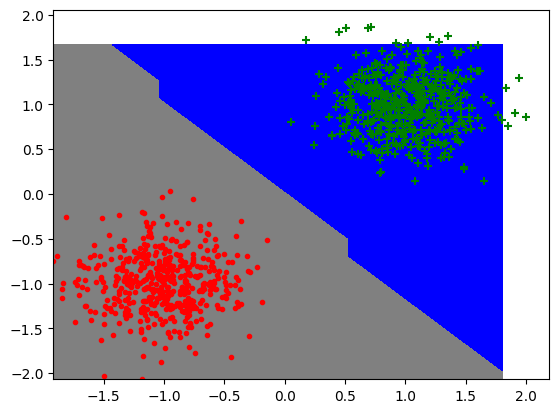

In [4]:
data_x,data_y = gen_arti(nbex=1000,data_type=0)
model = Lineaire(loss=perceptron_loss,loss_g=perceptron_grad,max_iter=1000,eps=0.01)
model.fit(data_x, data_y)
plot_frontiere(data_x,lambda x: model.predict(x),step=20)
plot_data(data_x,data_y)

In [24]:
#get data
def load_usps(fn):
    with open(fn,"r") as f:
        f.readline()
        data = [[float(x) for x in l.split()] for l in f if len(l.split())>2]
    tmp=np.array(data)
    return tmp[:,1:],tmp[:,0].astype(int)

def get_usps(l,datax,datay):
    if type(l)!=list:
        resx = datax[datay==l,:]
        resy = datay[datay==l]
        return resx,resy
    tmp =   list(zip(*[get_usps(i,datax,datay) for i in l]))
    tmpx,tmpy = np.vstack(tmp[0]),np.hstack(tmp[1])
    return tmpx,tmpy

def show_usps(data):
    plt.imshow(data.reshape((16,16)),interpolation="nearest",cmap="gray")


### Visualize some examples

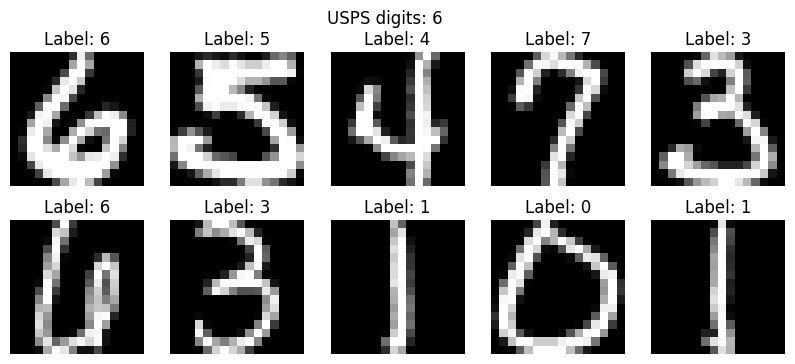

In [25]:
uspsdatatrain = "../data/USPS_train.txt"
uspsdatatest = "../data/USPS_test.txt"
alltrainx,alltrainy = load_usps(uspsdatatrain)
alltestx,alltesty = load_usps(uspsdatatest)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_usps(alltrainx[i])
    plt.title(f"Label: {int(alltrainy[i])}")
    plt.axis("off")
plt.suptitle("USPS digits: 6")
plt.show()


## Training perceptron class 6 vs 9

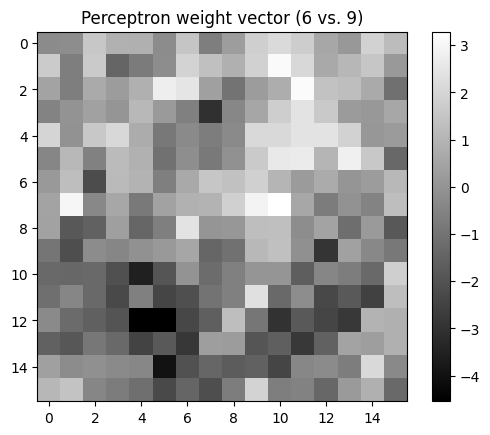

0.9942363112391931


In [26]:
neg = 9
pos = 6
datax, datay = get_usps([neg,pos], alltrainx, alltrainy)
testx, testy = get_usps([neg,pos], alltestx, alltesty)
datay = np.where(datay == neg, 1, -1) 
testy = np.where(testy == neg, 1, -1)

model = Lineaire()
model.fit(datax, datay)
show_usps(model.w)
plt.title("Perceptron weight vector (6 vs. 9)")
plt.colorbar()
plt.show()
print(model.score(testx, testy))

### Results

We obtain the weight matrix where we can observe the representation of the weights learned to classify digit as 6. We notice higher weight values in the shape of the digit as a class. Furthermore, if we look at white weights we can observe a 9. We can very nicely directly observe exact representation of the digits. 
We also obtain high accuracy of classification 99,7%. 
It is important to remember that this is still binary classification between two digits. So the classifier would not recognize other digits with the same set of weights. 

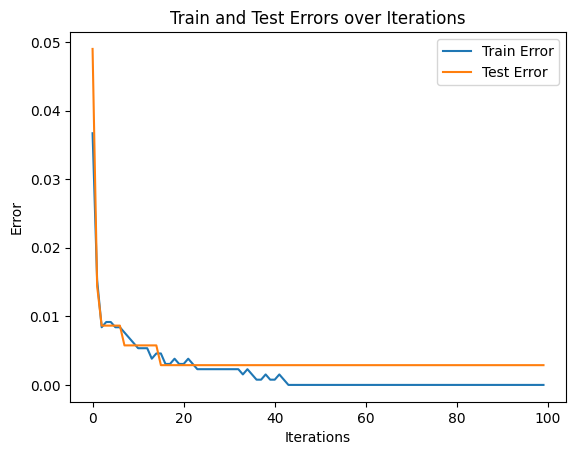

In [29]:
    model = Lineaire()
    model.fit(datax, datay, testx=testx, testy=testy)

    plt.plot(model.train_errors, label='Train Error')
    plt.plot(model.test_errors, label='Test Error')
    plt.xlabel('Iterations')
    plt.ylabel('Error')
    plt.legend()
    plt.title('Train and Test Errors over Iterations')
    plt.show()

We can observe that the error decreases with nb of iterations. There is some strange flactuation between 40-60 iterations. However, later in time the error stabilizes. We can see test error being slightly higher than train error, which makes sense given the model has been trained on the train data. Both errors are pretty similar to we can rule out overfitting. 

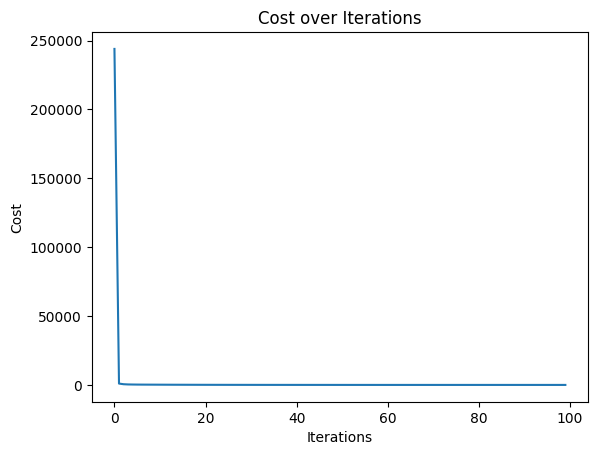

In [28]:

cost_history = model.fit(datax, datay, testx=testx, testy=testy)
plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost over Iterations')
plt.show()

Furthermore, we can observe how cost quickly decreases with iterations. We can assume the learning happens quickly and early in time.

## Training perceptron 6 vs all other classes

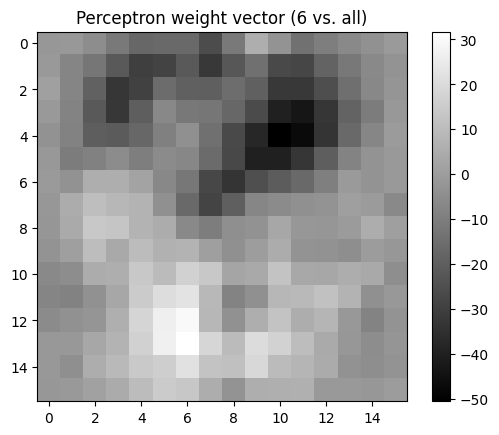

0.9835575485799701


In [13]:

class_1 = 6
datax, datay = alltrainx, alltrainy
testx, testy = alltestx, alltesty
datay = np.where(datay == class_1, 1, -1)  
testy = np.where(testy == class_1, 1, -1)
model = Lineaire()
model.fit(datax, datay)
show_usps(model.w)
plt.title(f"Perceptron weight vector (6 vs. all)")
plt.colorbar()
plt.show()
print(model.score(testx, testy))


Here again we can see high accuracy with classifying 6 vs non 6. Again, the weight matrix represents the digit. Compared to the previous weight matrix here it is more blurred. 

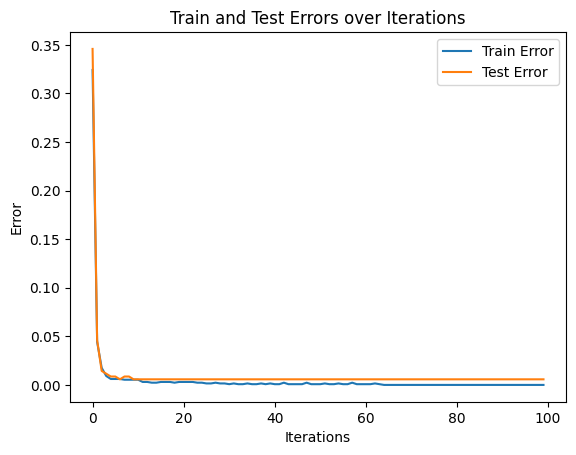

In [30]:

    model = Lineaire()
    model.fit(datax, datay, testx=testx, testy=testy)
    
    plt.plot(model.train_errors, label='Train Error')
    plt.plot(model.test_errors, label='Test Error')
    plt.xlabel('Iterations')
    plt.ylabel('Error')
    plt.legend()
    plt.title('Train and Test Errors over Iterations')
    plt.show()

Again, the error quickly decreases, reaching convergence to 0.01 (very low). Here train and test errors are very close to each other, so overfitting can be ruled out. In this case we have even better results than for 6 vs 9 classification. 

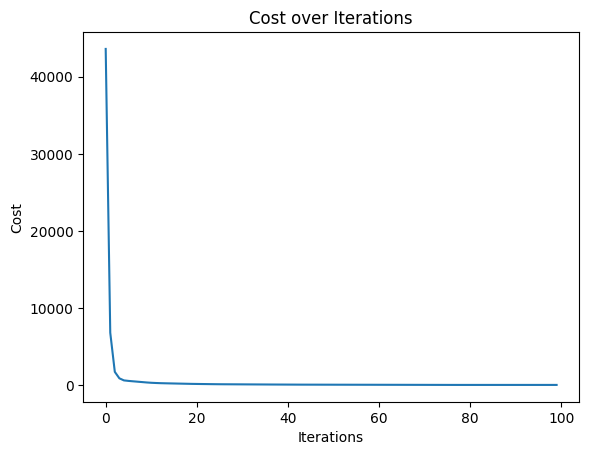

In [31]:

cost_history = model.fit(datax, datay, testx=testx, testy=testy)
plt.plot(cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost over Iterations')
plt.show()

Cost quickly goes down. It converges to 0 quickly. So again, fast and early learning. 

## Mini batch/Stochastic descent

Going through all of the examples in each iteration is costly in terms of time and computational power. That is why, mini batch descent can work as a more effective alternative taking a set of examples for each training epoch. Stochastic descent with shuffled examples can also work as an alternative, however more noisy than mini batch descent.

In [16]:
class Lineaire(object):
    def __init__(self,loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01,):
        self.max_iter, self.eps = max_iter,eps, 
        self.w = None
        self.loss,self.loss_g = loss,loss_g
        
    def fit(self,datax,datay,testx=None,testy=None,batch_size=None):
        cost_history = []
        self.train_errors = []
        self.test_errors = []
        m = datax.shape[0]

        datay = datay.reshape(-1, 1)
        if testx is not None and testy is not None:
            testy = testy.reshape(-1, 1)

        self.w = np.random.randn(datax.shape[1], 1)
        if batch_size is None:
            batch_size = m

        for iter in range(self.max_iter):
            indices = np.random.permutation(m)
            x_shiffled = datax[indices]
            y_shiffled = datay[indices]

            for i in range(0, m, batch_size):
                batch_x = x_shiffled[i:i+batch_size]
                batch_y = y_shiffled[i:i+batch_size]
                
                grad = self.loss_g(self.w, batch_x, batch_y)
                self.w -= self.eps * grad
            loss = self.loss(self.w, datax, datay)
            cost_history.append(np.sum(loss))

            self.train_errors.append(1-self.score(datax, datay))
            if testx is not None and testy is not None:
                self.test_errors.append(1-self.score(testx, testy))
        return cost_history
        
    def predict(self,datax):
        label = np.sign(datax @ self.w)
        return label

    def score(self,datax,datay):
        pred = self.predict(datax).reshape(-1)
        true = datay.reshape(-1)
        return np.mean(pred == true)

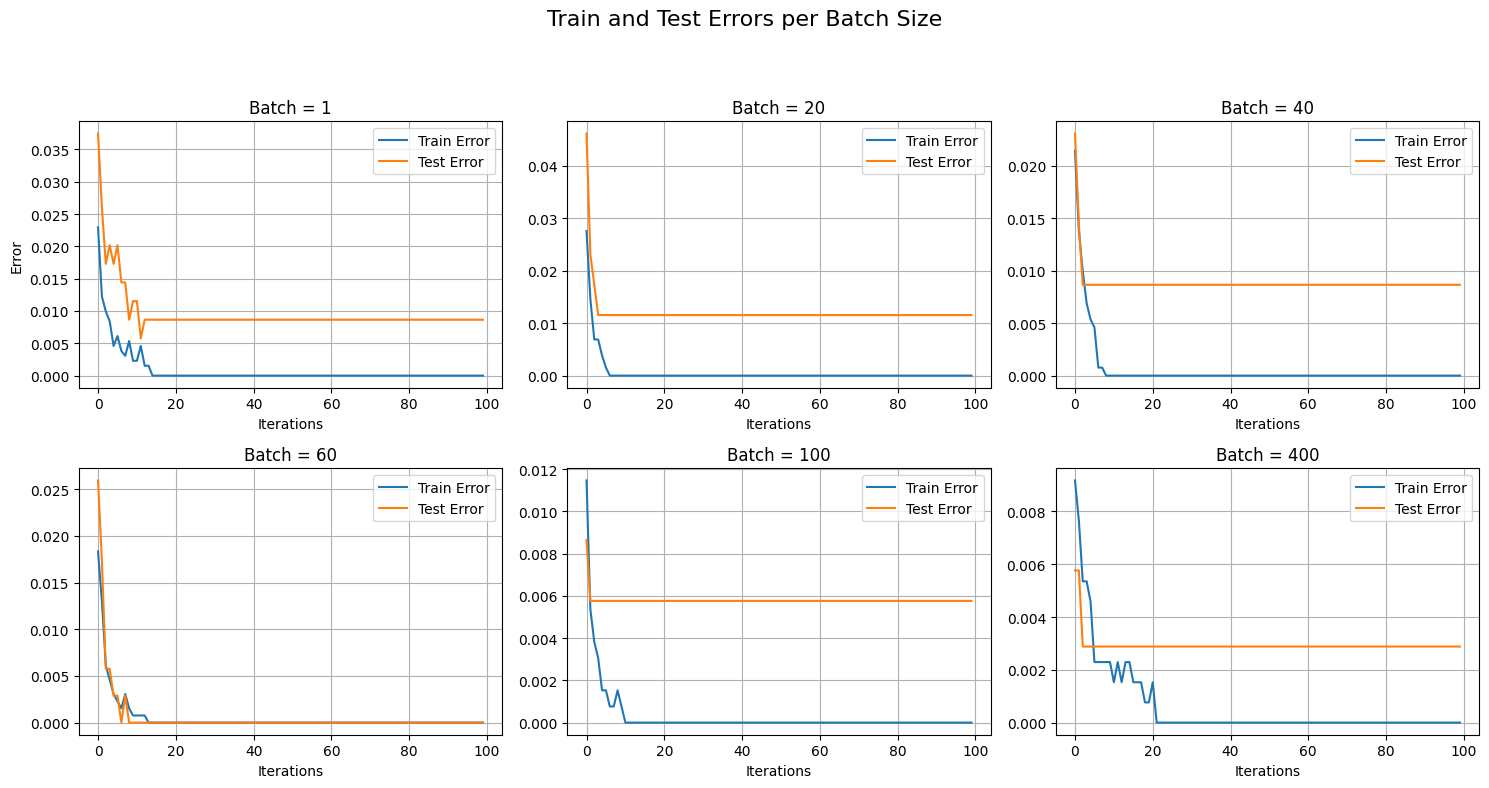

In [22]:
# Train the model
uspsdatatrain = "../data/USPS_train.txt"
uspsdatatest = "../data/USPS_test.txt"
alltrainx,alltrainy = load_usps(uspsdatatrain)
alltestx,alltesty = load_usps(uspsdatatest)
neg = 9
pos = 6
datax, datay = get_usps([neg,pos], alltrainx, alltrainy)
testx, testy = get_usps([neg,pos], alltestx, alltesty)
datay = np.where(datay == neg, 1, -1)
testy = np.where(testy == neg, 1, -1)

batch_size = [1,20,40,60,100,400]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, batch in enumerate(batch_size):
    model = Lineaire()
    model.fit(datax,datay,testx, testy, batch_size=batch)

    ax = axes[idx // 3, idx % 3]
    ax.plot(model.train_errors, label='Train Error')
    ax.plot(model.test_errors, label='Test Error')
    ax.set_title(f'Batch = {batch}')
    ax.set_xlabel('Iterations')
    if idx == 0:
        ax.set_ylabel('Error')
    ax.grid()
    ax.legend()

plt.suptitle('Train and Test Errors per Batch Size', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Results 

Here we can observe how the error changes depending on the batch size. Batch size of 1 is equivalent to taking all of the examples (stochastic descent). We observe the lower error/best performance for batch size each to 60. The worst performance is for batch size = 100. We can conclude that choosing appropriate batch size is important for learning and generalizability. If we take big batch size (100, 400) test and train error are quite far from each other which means less generalizability and possibly more overfitting. We can observe that stochastic descnet is similar to either low batch size or very high, which makes sense because if batch size is high we take again almost all of the examples. 
In this case we would choose batch size = 60 as an optimal hyperparameter. 

### Cost

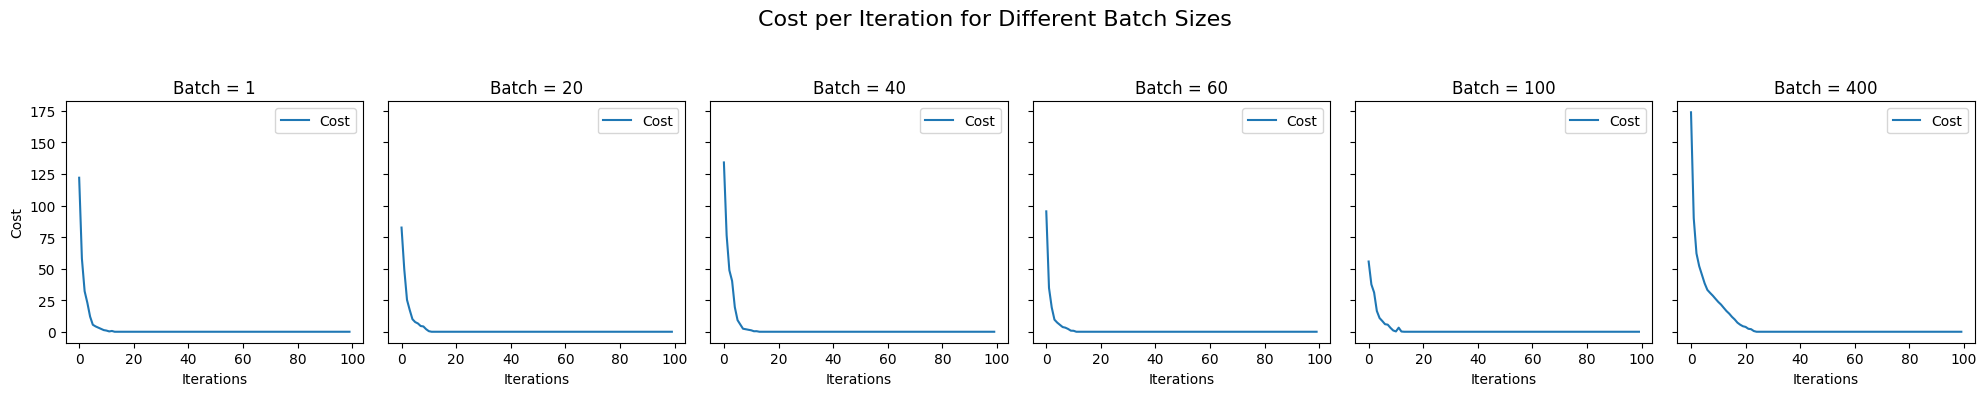

In [32]:
batch_size = [1, 20, 40, 60, 100, 400]
fig, axes = plt.subplots(1, len(batch_size), figsize=(20, 4), sharey=True)

for idx, batch in enumerate(batch_size):
    model = Lineaire()
    cost_history = model.fit(datax, datay,testx, testy, batch_size=batch)

    ax = axes[idx]
    ax.plot(cost_history, label='Cost')
    ax.set_title(f'Batch = {batch}')
    ax.set_xlabel('Iterations')
    if idx == 0:
        ax.set_ylabel('Cost')
    ax.legend()

plt.suptitle('Cost per Iteration for Different Batch Sizes', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Here we can observe that cost decreases quickly for all of the batch sizes. However, for some sizes it is faster (1,20,40,60). Here, for batch size 400 the cost takes the longest to reach the convergence at 0. Again we assume that batch size 60 is an optimal value.

## Noisy data analysis

Here we will do the same analysis but on noisy data. Since I started an analysis on USPS data i will compare those results to the same data set but with added noise. I add noise as changing 10 % of the labels to the wrong ones. 

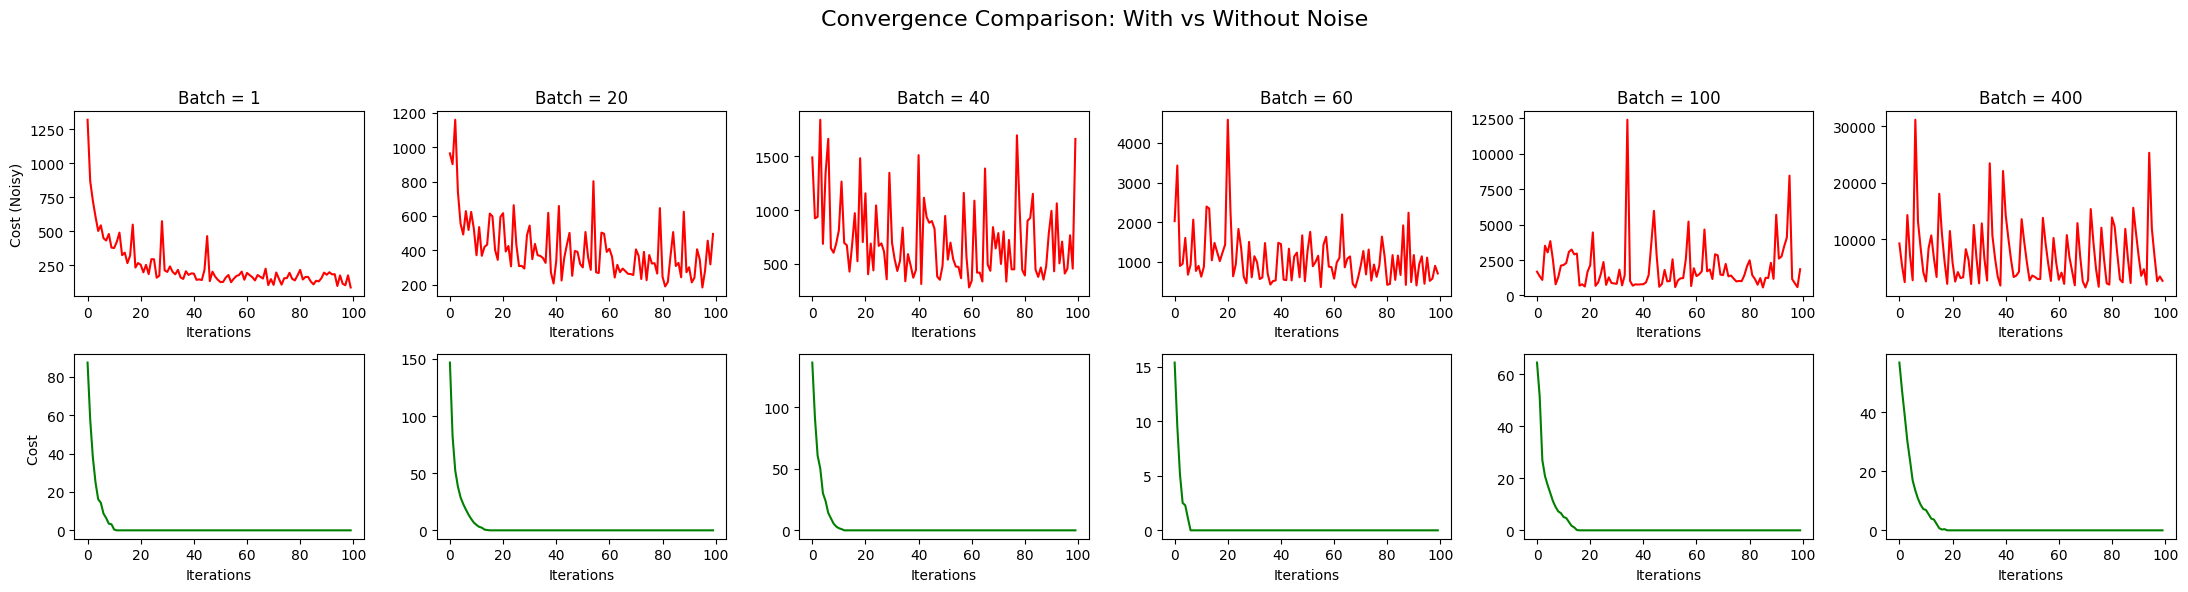

In [34]:

def noise(y, noise_level=0.1, seed=42):
    y_noisy = y.copy()
    n_samples = len(y)
    n_noisy = int(noise_level * n_samples)
    noisy_indices = np.random.choice(n_samples, n_noisy, replace=False)
    y_noisy[noisy_indices] *= -1  #change labels 
    return y_noisy

noisy_datay = noise(datay, noise_level=0.1)

batch_sizes = [1, 20, 40, 60, 100, 400]
fig, axes = plt.subplots(2, len(batch_sizes), figsize=(22, 6))

for idx, batch in enumerate(batch_sizes):

    model_noise = Lineaire()
    cost_history_noise = model_noise.fit(datax, noisy_datay, testx=testx, testy=testy, batch_size=batch)

    model_clean = Lineaire()
    cost_history_clean = model_clean.fit(datax, datay, testx=testx, testy=testy, batch_size=batch)

    axes[0, idx].plot(cost_history_noise, label='Noisy', color='r')
    axes[0, idx].set_title(f'Batch = {batch}')
    axes[0, idx].set_xlabel('Iterations')
    if idx == 0:
        axes[0, idx].set_ylabel('Cost (Noisy)')
    
    axes[1, idx].plot(cost_history_clean, label='Clean', color='g')
    axes[1, idx].set_xlabel('Iterations')
    if idx == 0:
        axes[1, idx].set_ylabel('Cost ')

fig.suptitle('Convergence Comparison: With vs Without Noise', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Results 

We can observe the difference in cost evolution given different data sets. In the noisy data set, the cost is also noisy, flactuating a lot. We can see very high cost values for batch size =100, 400 for noisy data. With the batch size = 1 the cost evolution (shape) approximates the one from non-noisy data, however with much higher values. 
We can observe large difference in performance between noisy and non-noisy data. In the noisy data there is no convergence of the model, in comparison to non-noisy where we see fast convergence to 0 cost. 

Those results show a limitation of the perceptron, which is not flexible enough to classify noisy data.

### Compare to previous example

We can plot noisy data from previous example and compare the performance to previous model (logistic and linear). Using perceptron we obtain the same decision boundary. This is because for all of the three models the decision boundary is linear. This is a limitation because they cannot deal with non-linearly separable data.

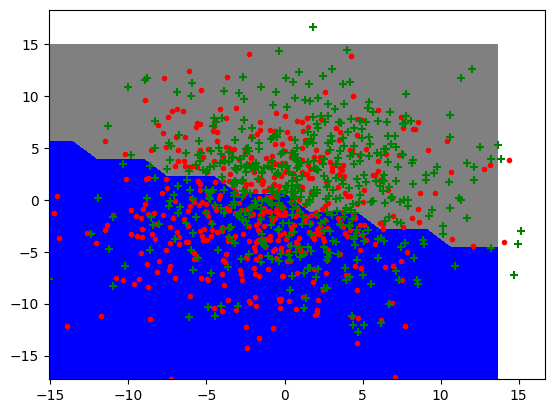

In [35]:
data_x, data_y = gen_arti(nbex=1000, data_type=0, epsilon=5)
model = Lineaire(loss=perceptron_loss, loss_g=perceptron_grad, max_iter=1000, eps=0.01)
model.fit(data_x, data_y)
plot_frontiere(data_x,lambda x: model.predict(x),step=20)
plot_data(data_x,data_y)


## Projection 

To account for the previous limitations, in classifying noisy or non-separable data we can use a method to increase the dimensions of the data. This is done using projection, which projects the data into higher dimensions. This method can help with classifying linearly non-separable data. 

In [36]:
def proj_poly(datax):
    d = datax.shape[1]
    poly_proj = [np.ones((datax.shape[0], 1)),datax]
    poly_proj.append(datax**2)
    for i in range(d):
        for j in range(i+1,d):
            poly_proj.append((datax[:,i]*datax[:,j]).reshape(-1, 1))
    poly_proj = np.hstack(poly_proj)
    return poly_proj

def proj_biais(datax):
    n = datax.shape[0]
    return np.hstack([np.ones((n, 1)), datax])
    
def proj_gauss(datax, base, sigma):
    dist_sq = np.sum((datax[:, np.newaxis] - base[np.newaxis, :]) ** 2, axis=2)
    projection = np.exp(-dist_sq / (2 * sigma))
    return projection




In [37]:
class Lineaire(object):
    def __init__(self,loss=perceptron_loss,loss_g=perceptron_grad,max_iter=100,eps=0.01,projection=None):
        self.max_iter, self.eps = max_iter,eps
        self.w = None
        self.loss,self.loss_g = loss,loss_g
        self.projection = projection
        
    def fit(self,datax,datay,testx=None,testy=None):
        cost_history = []
        self.train_errors = []
        self.test_errors = []

        if self.projection:
            datax = self.projection(datax)
            if testx is not None:
                testx = self.projection(testx)

        datay = datay.reshape(-1, 1)
        if testx is not None and testy is not None:
            testy = testy.reshape(-1, 1)

        self.w = np.random.randn(datax.shape[1], 1)

        for iter in range(self.max_iter):
            loss = self.loss(self.w, datax, datay)
            cost_history.append(np.sum(loss))
            grad = self.loss_g(self.w, datax, datay)
            self.w -= self.eps * grad

            self.train_errors.append(1-self.score(datax, datay,projected=True))
            if testx is not None and testy is not None:
                self.test_errors.append(1-self.score(testx, testy,projected=True))
        return cost_history
        
    def predict(self,datax,projected=False):
        if self.projection and not projected:
            datax = self.projection(datax)
        label = np.sign(datax @ self.w)
        return label

    def score(self,datax,datay,projected=False):
        pred = self.predict(datax,projected=projected).flatten()
        return np.mean(pred==datay.flatten())
    


In [38]:
def hinge_loss(w, x, y, alpha, lambda_):
    y = y.reshape(-1, 1)
    h_loss = np.maximum(0, alpha - y * (x @ w))+ lambda_ * np.linalg.norm(w)**2
    return h_loss

def hinge_grad(w, x, y, alpha, lambda_):
    y = y.reshape(-1, 1)
    margins = alpha - y * (x @ w)
    mask = (margins > 0).astype(float)
    grad_hinge = -x.T @ (y*mask) + 2 * lambda_ * w
    return grad_hinge

## Polynomial projection


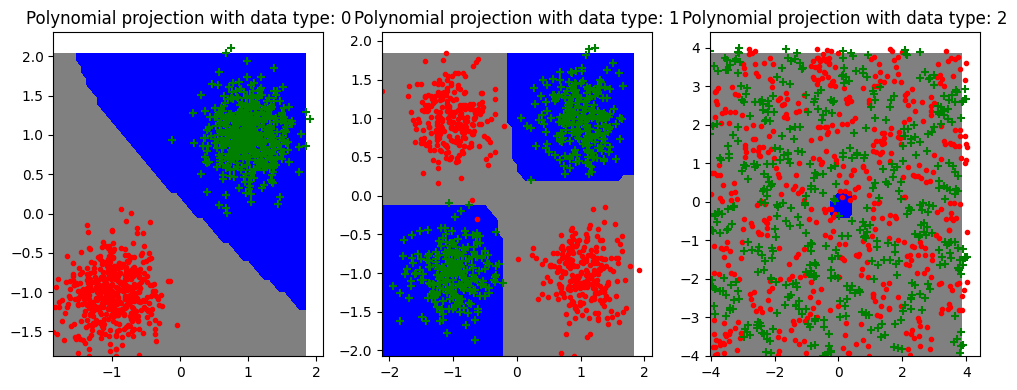

In [41]:
data_type = [0, 1, 2]  
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, dtype in enumerate(data_type):
    datax, datay = gen_arti(nbex=1000, data_type=dtype)  
    
    model = Lineaire(projection=proj_poly)  
    model.fit(datax, datay)  

    plt.sca(axes[i])
    plot_frontiere(datax, lambda x: model.predict(x), step=50)  
    plot_data(datax, datay)  
    plt.title(f"Polynomial projection with data type: {dtype}")


plt.tight_layout()
plt.show()


### Results

We can observe that in this case the model can seperate different types of data better than before. With very noisy data it is difficult to seperate the data because there is no structure within the data. We can see that in data type 2 the model is quite bad which makes sense since there is no visible pattern in the data even when projected onto higher dimensions.

## Gaussian projection

Base in the Gaussian projection is chosen randomly from a set of point from the data with dimensions m (hyperparameter) and nb of dimensions from the original dataset. 

(50, 2)
(50, 2)
(50, 2)


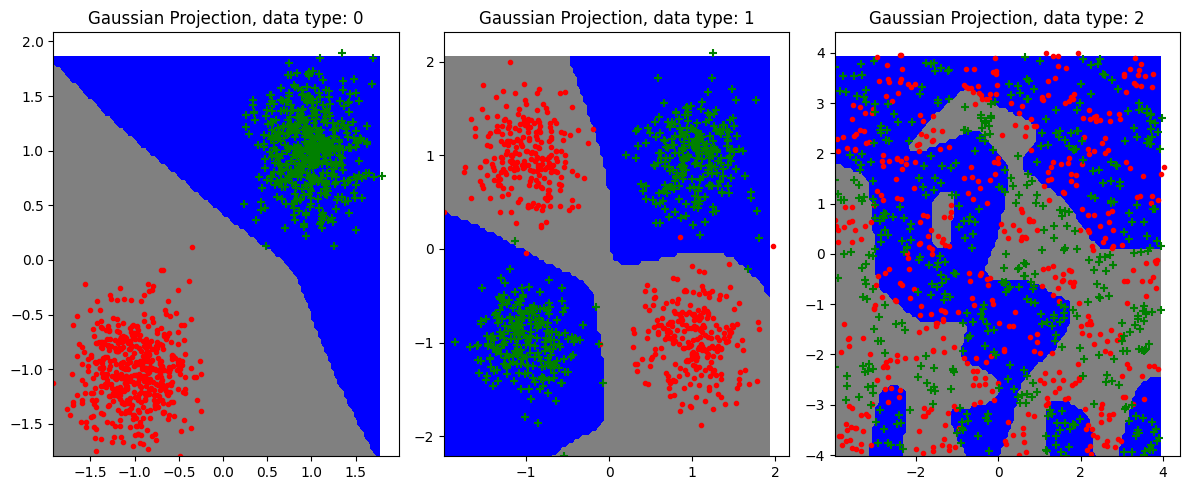

In [43]:
data_type = [0, 1, 2]  
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, dtype in enumerate(data_type):
    datax, datay = gen_arti(nbex=1000, data_type=dtype)  
    b = 50  # Number of base points 
    indices = np.random.choice(datax.shape[0], b, replace=False)
    base = datax[indices]
    print(base.shape)

    sigma = 0.2
    proj_func = lambda x: proj_gauss(x, base, sigma)  
    

    model = Lineaire(projection=proj_func)  
    model.fit(datax, datay)  

    plt.sca(axes[i])
    plot_frontiere(datax, lambda x: model.predict(x), step=100)  
    plot_data(datax, datay)  
    plt.title(f"Gaussian Projection, data type: {dtype}")


plt.tight_layout()
plt.show()


### Results 

Here we can observe that the decision boundary is even smoother than in the polynomial projection. We can observe some pattern/classification emerging in the gaussian projection. The classification is still not perfect in the noisy data, however, might be better than other methods we have studied.

## Experiment with hyperparameters

### Number of point in the projection base and sigma 

sigma is a hyperparameter which controls the spread of the kernel around the point. The number of base points control the nb of featured in new space/nb of dimensions. With more base points we would expect more complexity of the model, further might improve performance with noisy data, better fit.

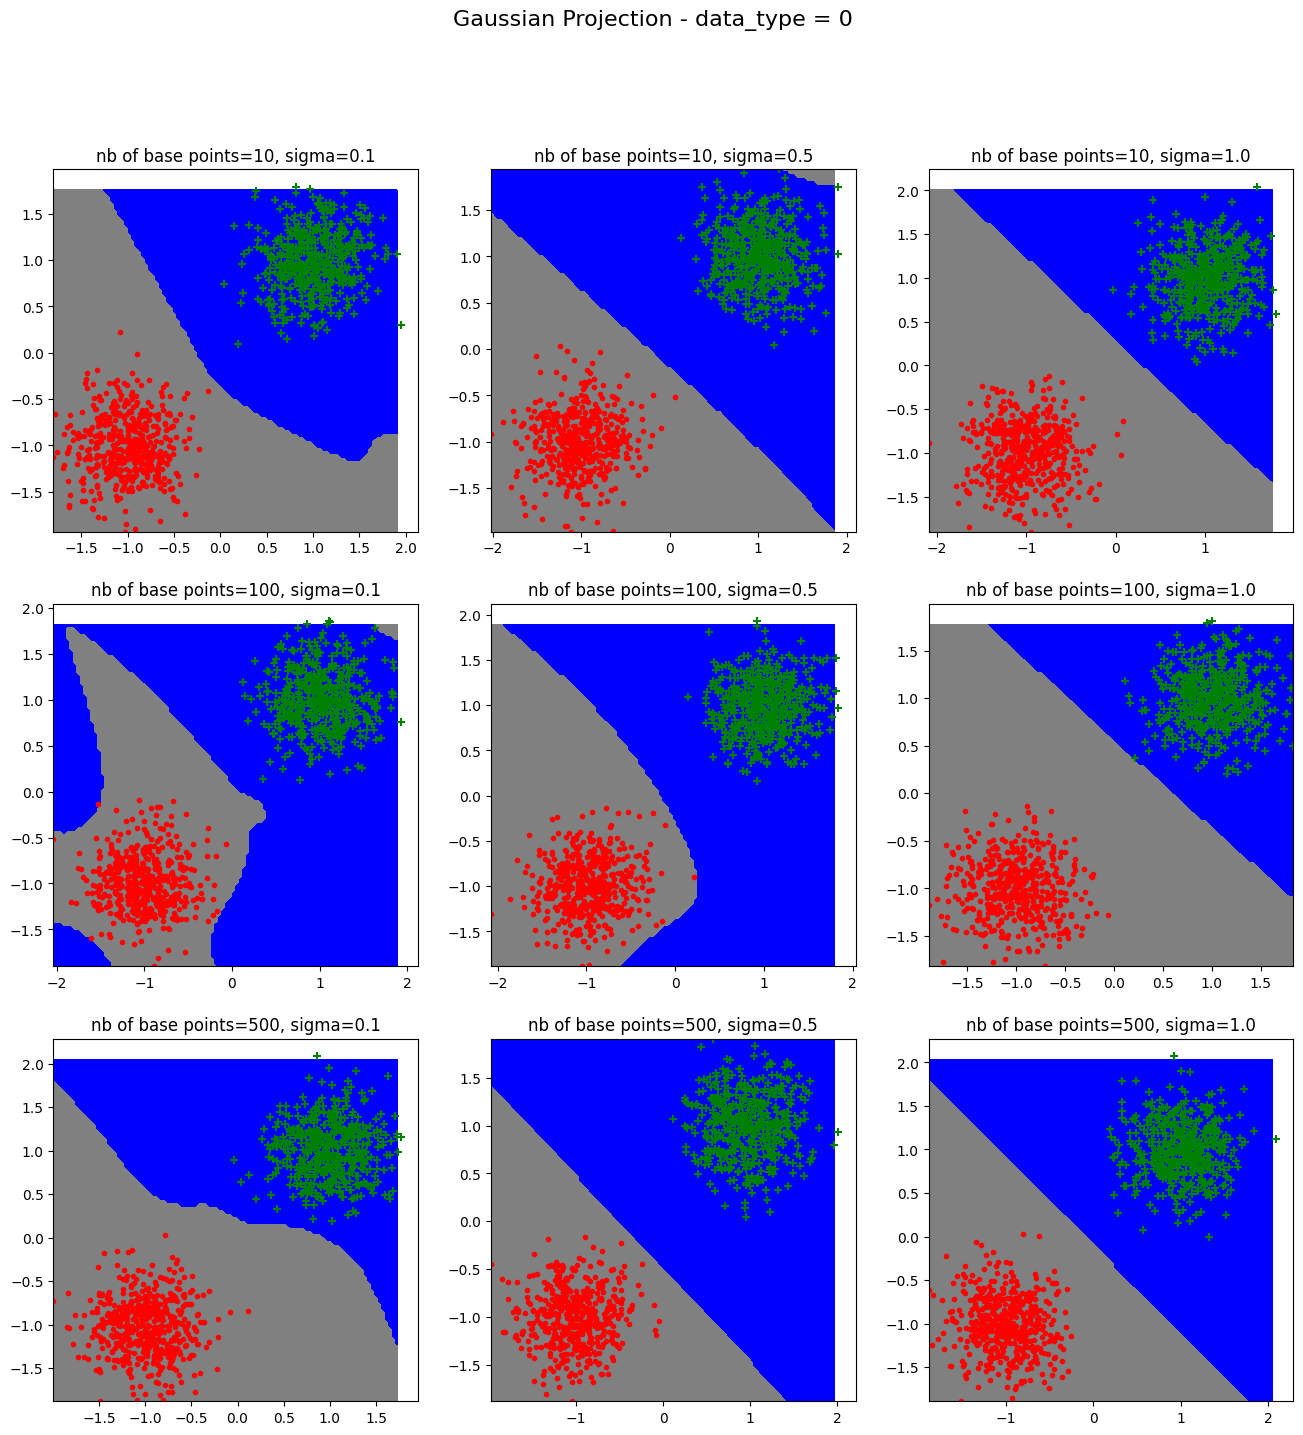

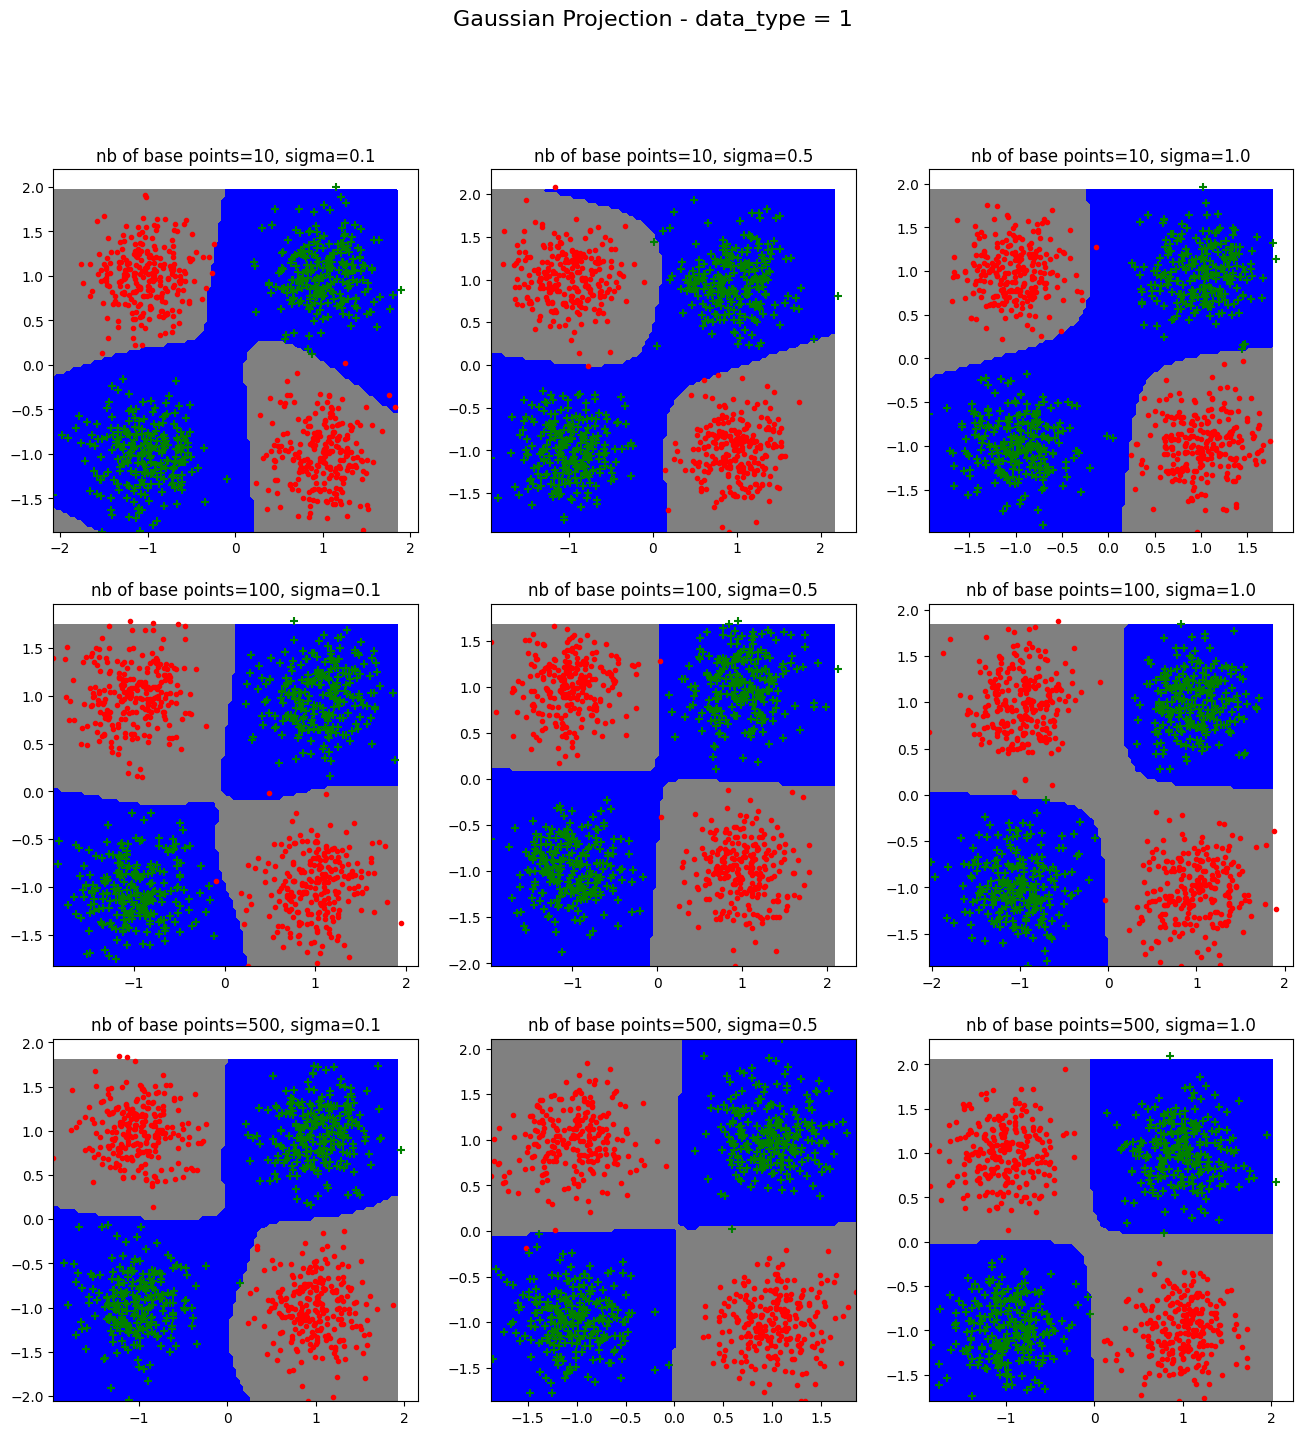

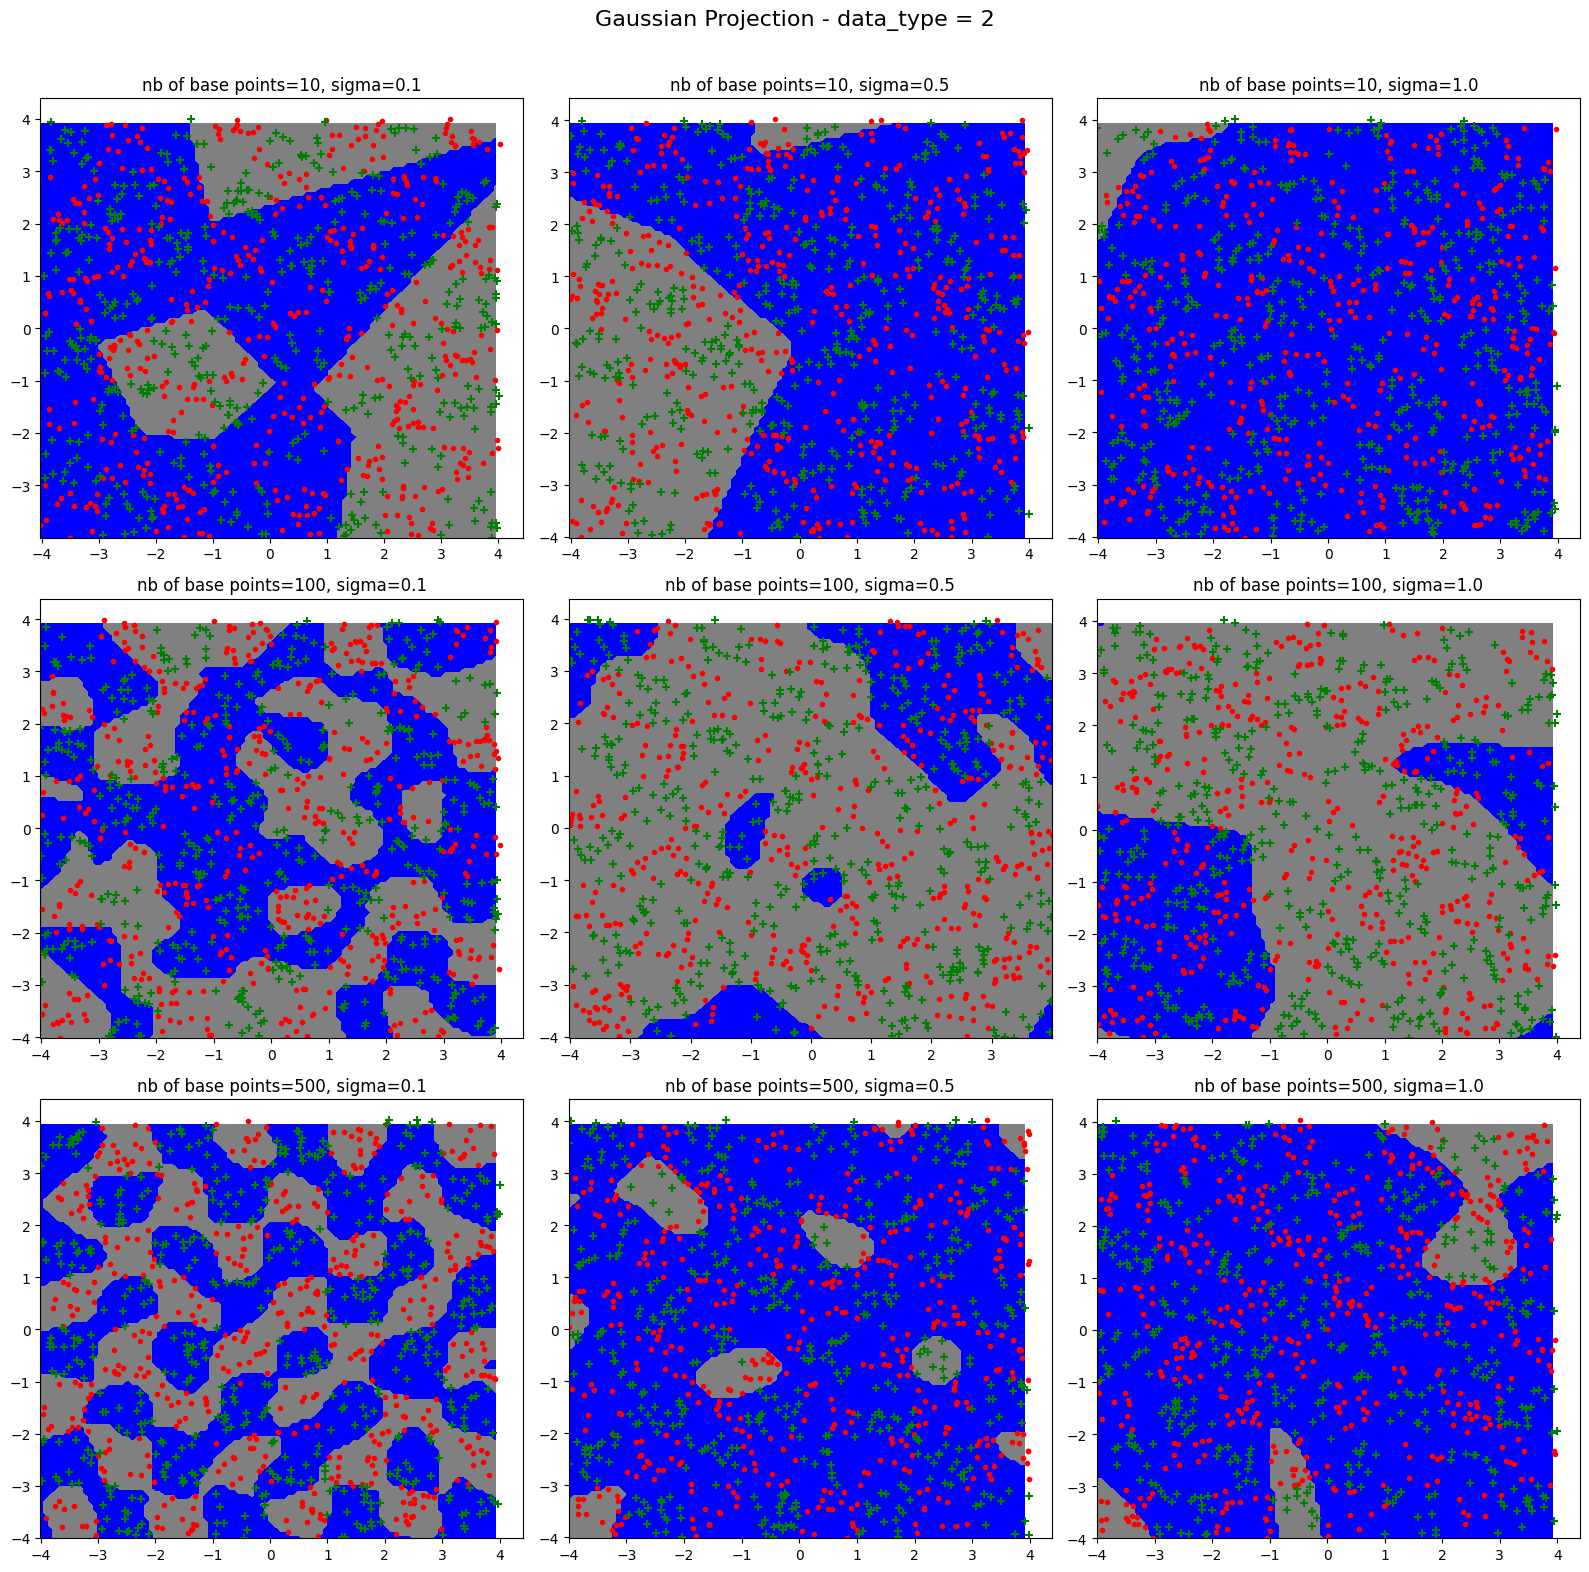

In [46]:
data_type = [0, 1, 2] 
nb_base_points = [10,100,500]
sigmas = [0.1, 0.5, 1.0]


for i, dtype in enumerate(data_type):
    fig, axes = plt.subplots(3,3, figsize=(16, 16))
    for j, base_points in enumerate(nb_base_points):
        for k, sigma in enumerate(sigmas):
            datax, datay = gen_arti(nbex=1000, data_type=dtype)  
            b = base_points

            indices = np.random.choice(datax.shape[0], b, replace=False)
            base = datax[indices]

            proj_func = lambda x: proj_gauss(x, base, sigma) 
    

            model = Lineaire(projection=proj_func)  
            model.fit(datax, datay)  
            plt.suptitle(f"Gaussian Projection - data_type = {dtype}", fontsize=16)
            ax = axes[j, k]
            plt.sca(ax)
            plot_frontiere(datax, lambda x: model.predict(x), step=100)
            plot_data(datax, datay)
            ax.set_title(f"nb of base points={base_points}, sigma={sigma}")


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Results 

Data type 0 - linear separation
We can observe smoother boundaries with larger nb of base points. With high sigma however, the decision boundary resembles the one given by classical percpetron, linear decision boundary. 

Data type 1 
Here we can observe good performance across all the parameter values. If we look closely model with small nb of base pointa or high sigma may misclassify some of the examples. However, it seems like the model is insensitive to change of hyperparameters for this problem.

Data type 2
In this case we can see the difference in behavior depending on the parameters. Here the model with high nb of base points and low sigma is significantly 'better' than the rest of the models. It might be due to projecting each data point into high dimensions and with low sigma being narrowly centered around that point. With this method we should be alert of overfitting as we almost perfect draw a boundary surrounding each point. Depending on the problem this model might be very useful or meaningless. We can notive that classification of noisy data is the most sensitive to hyperparameter changes. 



## Regularization

- Alpha - mean how confident do we want to be in our decision, sets a boundary, penalizes points that are correctly classified, but below the margin
- Lambda - is a regularization term, with large lamda the model keeps the weights low, controlling for overshoting

$$ \text{hinge\_loss}(w, x, y, \alpha, \lambda) = \max(0,\ \alpha - y \cdot \langle w, x \rangle) + \lambda \|w\|^2 $$ 

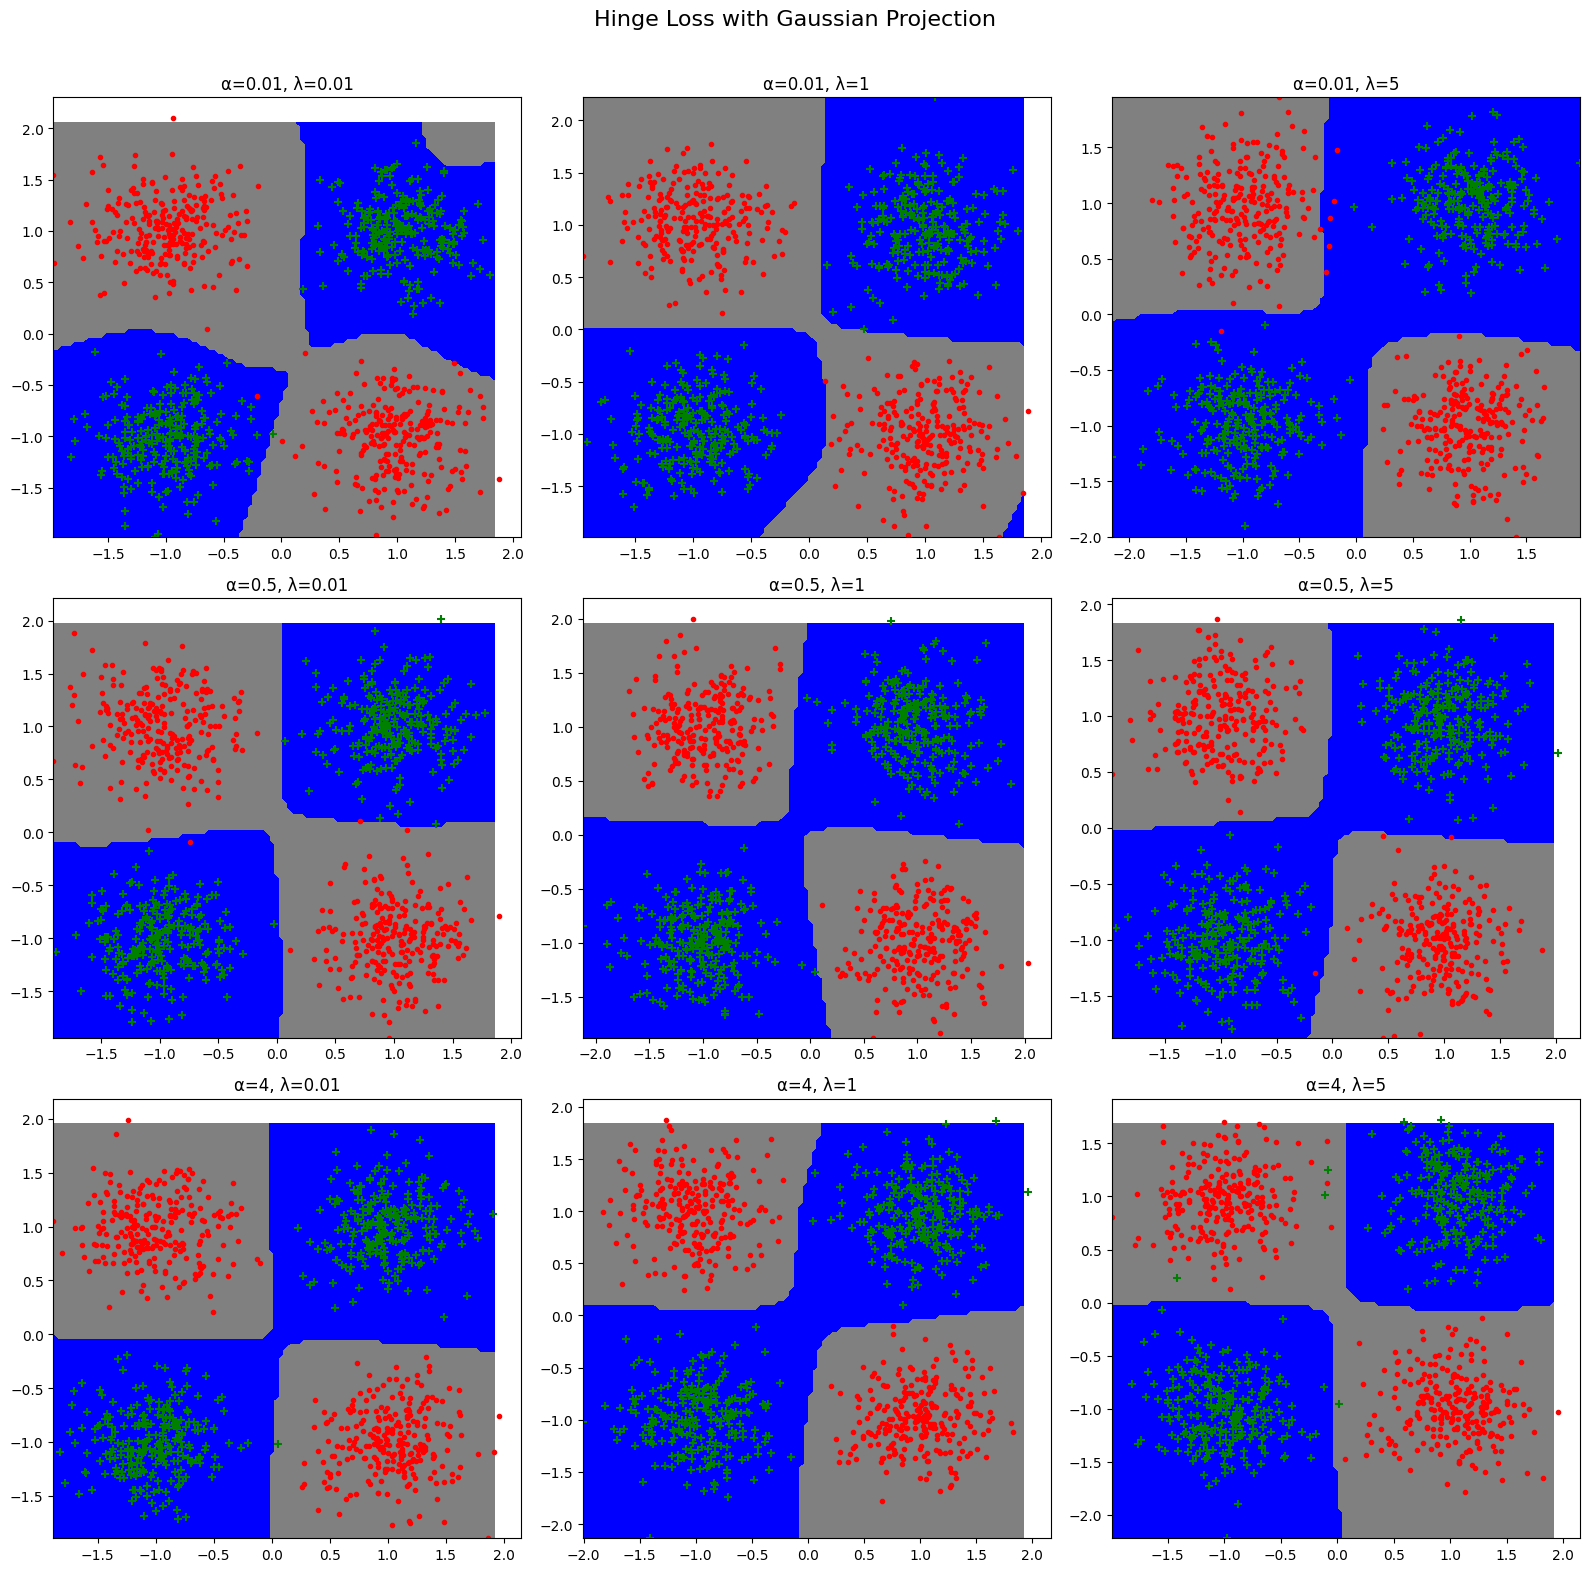

In [51]:
alphas = [0.01, 0.5, 4]
lambdas = [0.01, 1, 5]
fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for i, alpha in enumerate(alphas):
    for j, lambda_ in enumerate(lambdas):
        datax, datay = gen_arti(nbex=1000, data_type=1) 
        base = datax[np.random.choice(datax.shape[0], 50, replace=False)]
        sigma = 0.2
        hloss = lambda w, x, y: hinge_loss(w, x, y, alpha=alpha, lambda_=lambda_)
        hgrad = lambda w, x, y: hinge_grad(w, x, y, alpha=alpha, lambda_=lambda_)
        proj_func = lambda x: proj_gauss(x, base, sigma)
        model = Lineaire(loss=hloss, loss_g=hgrad, projection=proj_func)
        model.fit(datax, datay)

        ax = axes[i, j]
        plt.sca(ax)
        plot_frontiere(datax, lambda x: model.predict(x), step=100)
        plot_data(datax, datay)
        ax.set_title(f"α={alpha}, λ={lambda_}")

plt.suptitle("Hinge Loss with Gaussian Projection", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Results

We can observe that with lambda being small decision boundaries are more flexible and smooth, compared to simpler boundaries with higher lambda values. 
With low values of alpha the boundary seems more flexible around the points. 

This can relate to SVM in the way that we care about the confidence of the decision, which is a key component of SVM. We are trying to find the best fit but with some margin preserved. SVM method is a good balance between overfitting and confidence. 

## SVM 

### Sklearn exploration

In [52]:
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


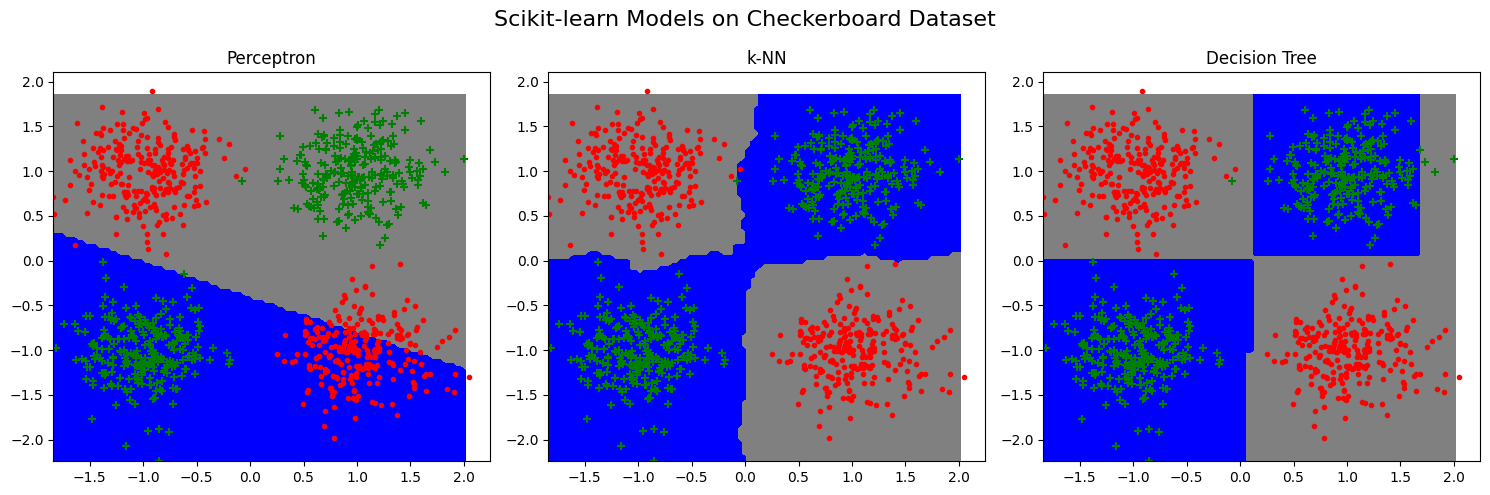

In [58]:

datax, datay = gen_arti(nbex=1000, data_type=1)  
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(datax, datay, test_size=0.3, random_state=42)
y_train = y_train.ravel()
y_test = y_test.ravel()
# Define models
models = {
    "Perceptron": Perceptron(max_iter=1000, tol=1e-3),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    ax = axes[i]
    plt.sca(ax)
    plot_frontiere(datax, lambda x: model.predict(x), step=100)
    plot_data(datax, datay)
    ax.set_title(f"{name}")

plt.suptitle("Scikit-learn Models on Checkerboard Dataset", fontsize=16)
plt.tight_layout()
plt.show()


We can observe how different methods yield different decision boundaries

## Explore different kernels and their parameters


In [59]:

def plot_frontiere_proba(data , f , step=20):
    grid , x, y = make_grid(data=data , step=step) 
    plt.contourf(x, y, f(grid).reshape(x.shape), 255)

In [60]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [85]:
datax, datay = gen_arti(nbex=1000, data_type=1)
X_train, X_test, y_train, y_test = train_test_split(datax, datay, test_size=0.3, random_state=42)
y_train = y_train.ravel()
y_test = y_test.ravel()

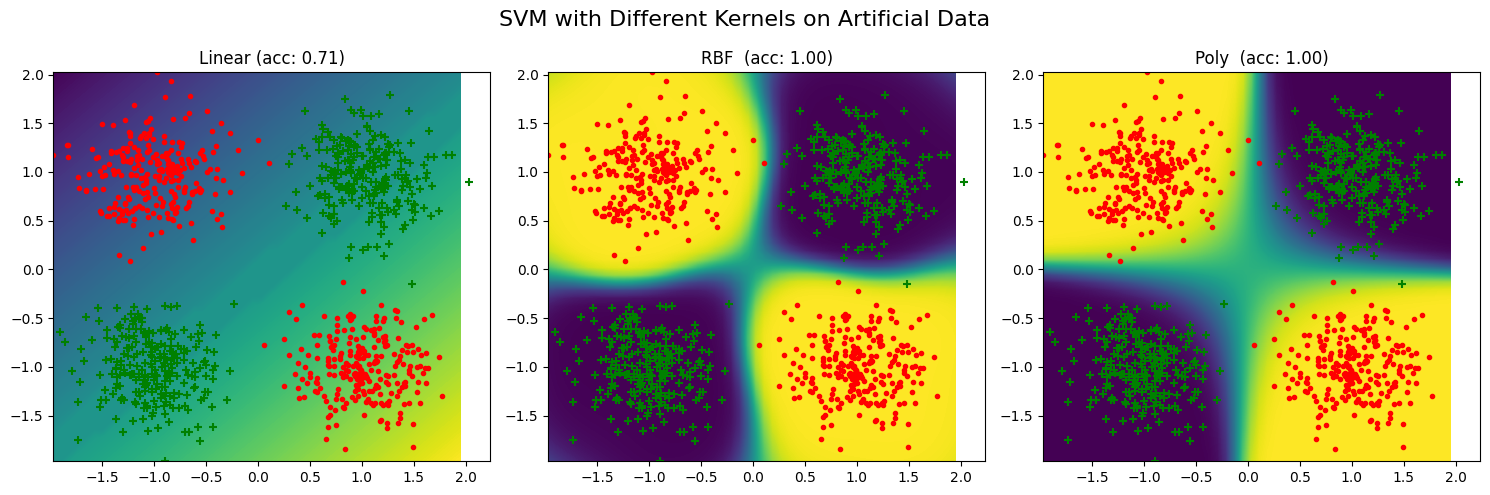

In [80]:
kernels = {
    "Linear": SVC(kernel='linear', C=1.0, probability=True),
    "RBF ": SVC(kernel='rbf', gamma=2, C=1, probability=True),
    "Poly ": SVC(kernel='poly', degree=2, C=1.0, probability=True)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, kernel_n) in enumerate(kernels.items()):
    kernel_n.fit(X_train, y_train)
    acc = accuracy_score(y_test, kernel_n.predict(X_test))

    ax = axes[i]
    plt.sca(ax)
    plot_frontiere_proba(datax, lambda x: kernel_n.predict_proba(x)[: ,0] , step=50)
    plot_data(datax, datay)
    ax.set_title(f"{name} (acc: {acc:.2f})")

plt.suptitle("SVM with Different Kernels on Artificial Data", fontsize=16)
plt.tight_layout()
plt.show()

### Results 
We can again observe different decision boundaries based on different kernels. Similar results to previous projections.

### Different parameters

- C - Regularization parameter. The strength of the regularization is inversely proportional to C
- gamma - the influence of a single example, high gamma values narrow kernel 

### Linear Kernel

Support Vectors for C=0.01: 689
Support Vectors for C=0.1: 689
Support Vectors for C=1: 683
Support Vectors for C=10: 683
Support Vectors for C=100: 683


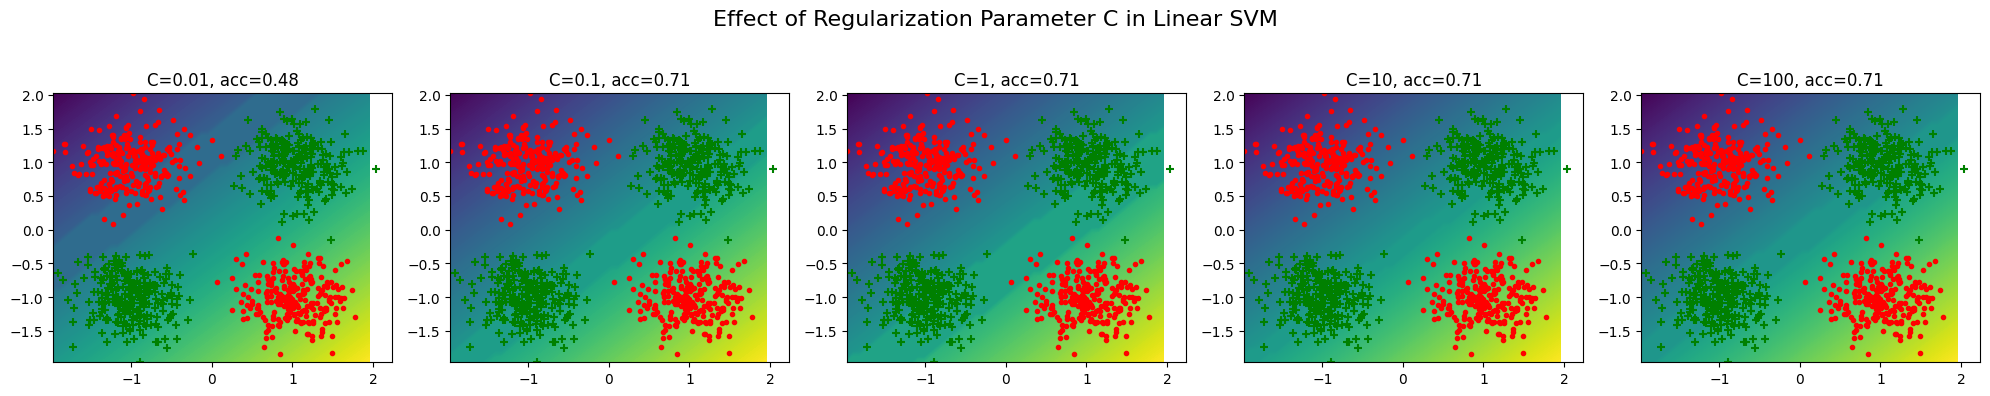

In [81]:

C_values = [0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

for i, C_val in enumerate(C_values):
    svm = SVC(kernel='linear', C=C_val, probability=True)
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test))
    sv = svm.support_vectors_
    print(f"Support Vectors for C={C_val}: {len(sv)}")
    ax = axes[i]
    plt.sca(ax)
    plot_frontiere_proba(datax, lambda x: svm.predict_proba(x)[: ,0] , step=50)
    plot_data(datax, datay)
    ax.set_title(f"C={C_val}, acc={acc:.2f}")


plt.suptitle("Effect of Regularization Parameter C in Linear SVM", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Results 

Here decision boundaries are almost the same for different parameters C values. We can see that the number of support vecotrs does not change with parameters. 

### RBF Kernel

Support Vectors for C=0.01, gamma=0.01: 692
Support Vectors for C=0.01, gamma=10: 694
Support Vectors for C=0.01, gamma=100: 696
Support Vectors for C=0.1, gamma=0.01: 693
Support Vectors for C=0.1, gamma=10: 307
Support Vectors for C=0.1, gamma=100: 695
Support Vectors for C=100, gamma=0.01: 112
Support Vectors for C=100, gamma=10: 133
Support Vectors for C=100, gamma=100: 488


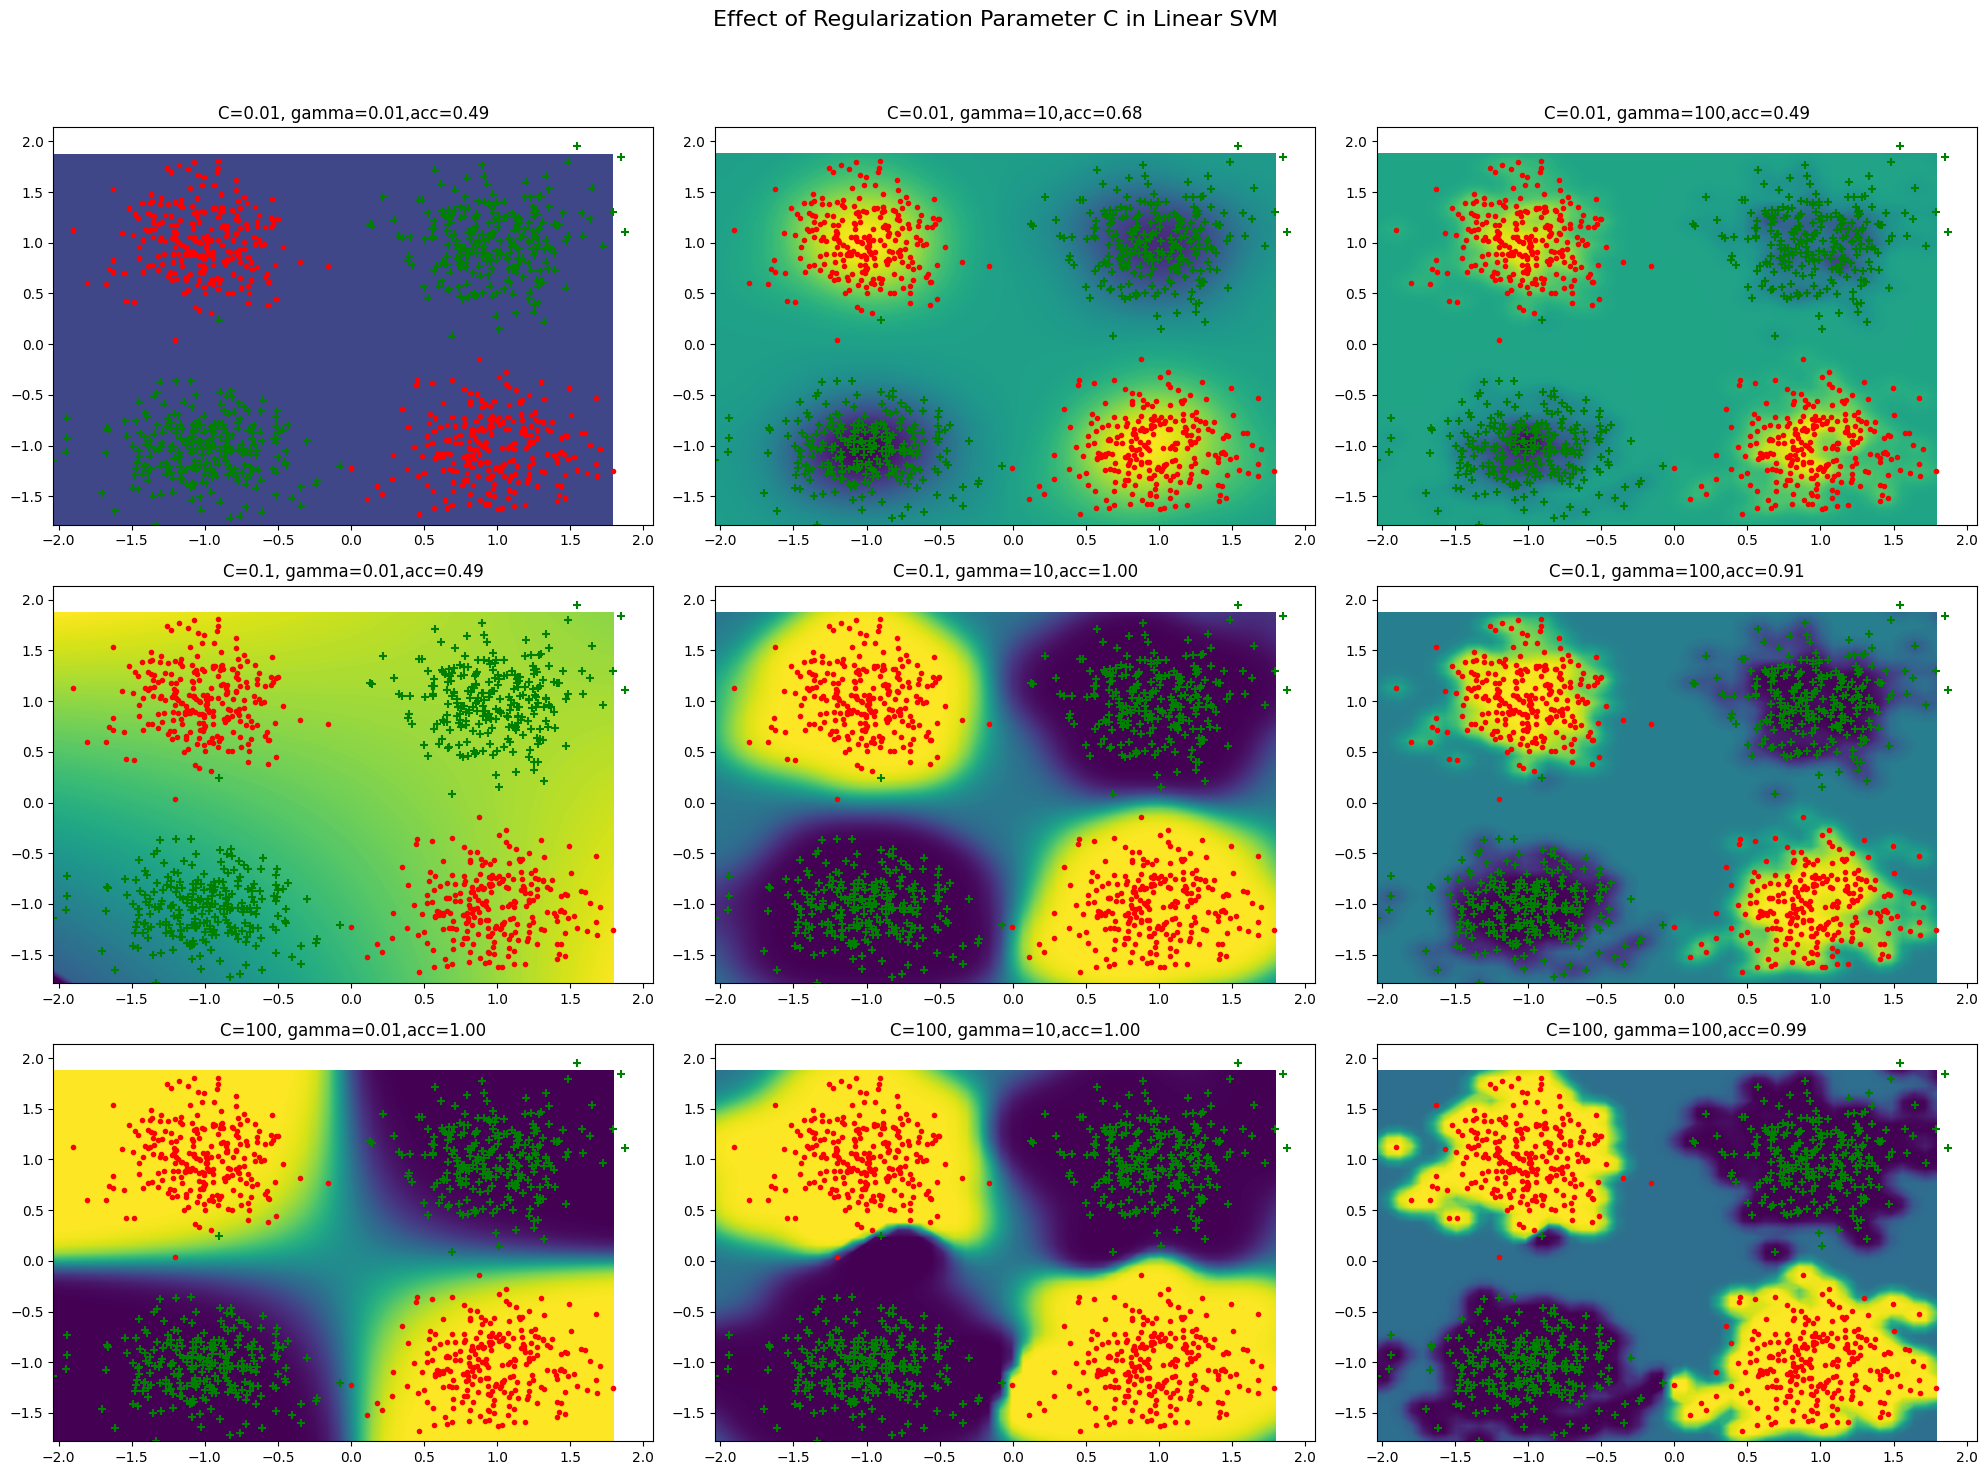

In [88]:

C_values = [0.01, 0.1, 100]
gamma_values = [0.01, 10, 100]

fig, axes = plt.subplots(len(C_values), len(gamma_values), figsize=(20, 15))

for i, C_val in enumerate(C_values):
    for j, gamma_val in enumerate(gamma_values):

        svm = SVC(kernel='rbf', gamma = gamma_val, C=C_val, probability=True)
        svm.fit(X_train, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test))
        sv = svm.support_vectors_
        print(f"Support Vectors for C={C_val}, gamma={gamma_val}: {len(sv)}")
        
        ax = axes[i,j]
        plt.sca(ax)
        plot_frontiere_proba(datax, lambda x: svm.predict_proba(x)[: ,0] , step=50)
        plot_data(datax, datay)
        ax.set_title(f"C={C_val}, gamma={gamma_val},acc={acc:.2f}")

plt.suptitle("Effect of Regularization Parameter C in Linear SVM", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Results 

In this case we can observe difference between models performance given the parameters.With more gamma there is a better fit to the data, can end up in overfitting if gamma is too high. However, we can observe similar behvaior with small C values that also producde overfitting. The most optimal are middle values which balance between generalizability and fitting the data.  We can see that with low C values there are many support vectors and this number decreases with high C values. 

### Polynomial kernel

Support Vectors for C=0.01, degree=2: 378
Support Vectors for C=0.01, degree=4: 416
Support Vectors for C=0.01, degree=6: 434
Support Vectors for C=1, degree=2: 35
Support Vectors for C=1, degree=4: 70
Support Vectors for C=1, degree=6: 117
Support Vectors for C=10, degree=2: 14
Support Vectors for C=10, degree=4: 29
Support Vectors for C=10, degree=6: 53


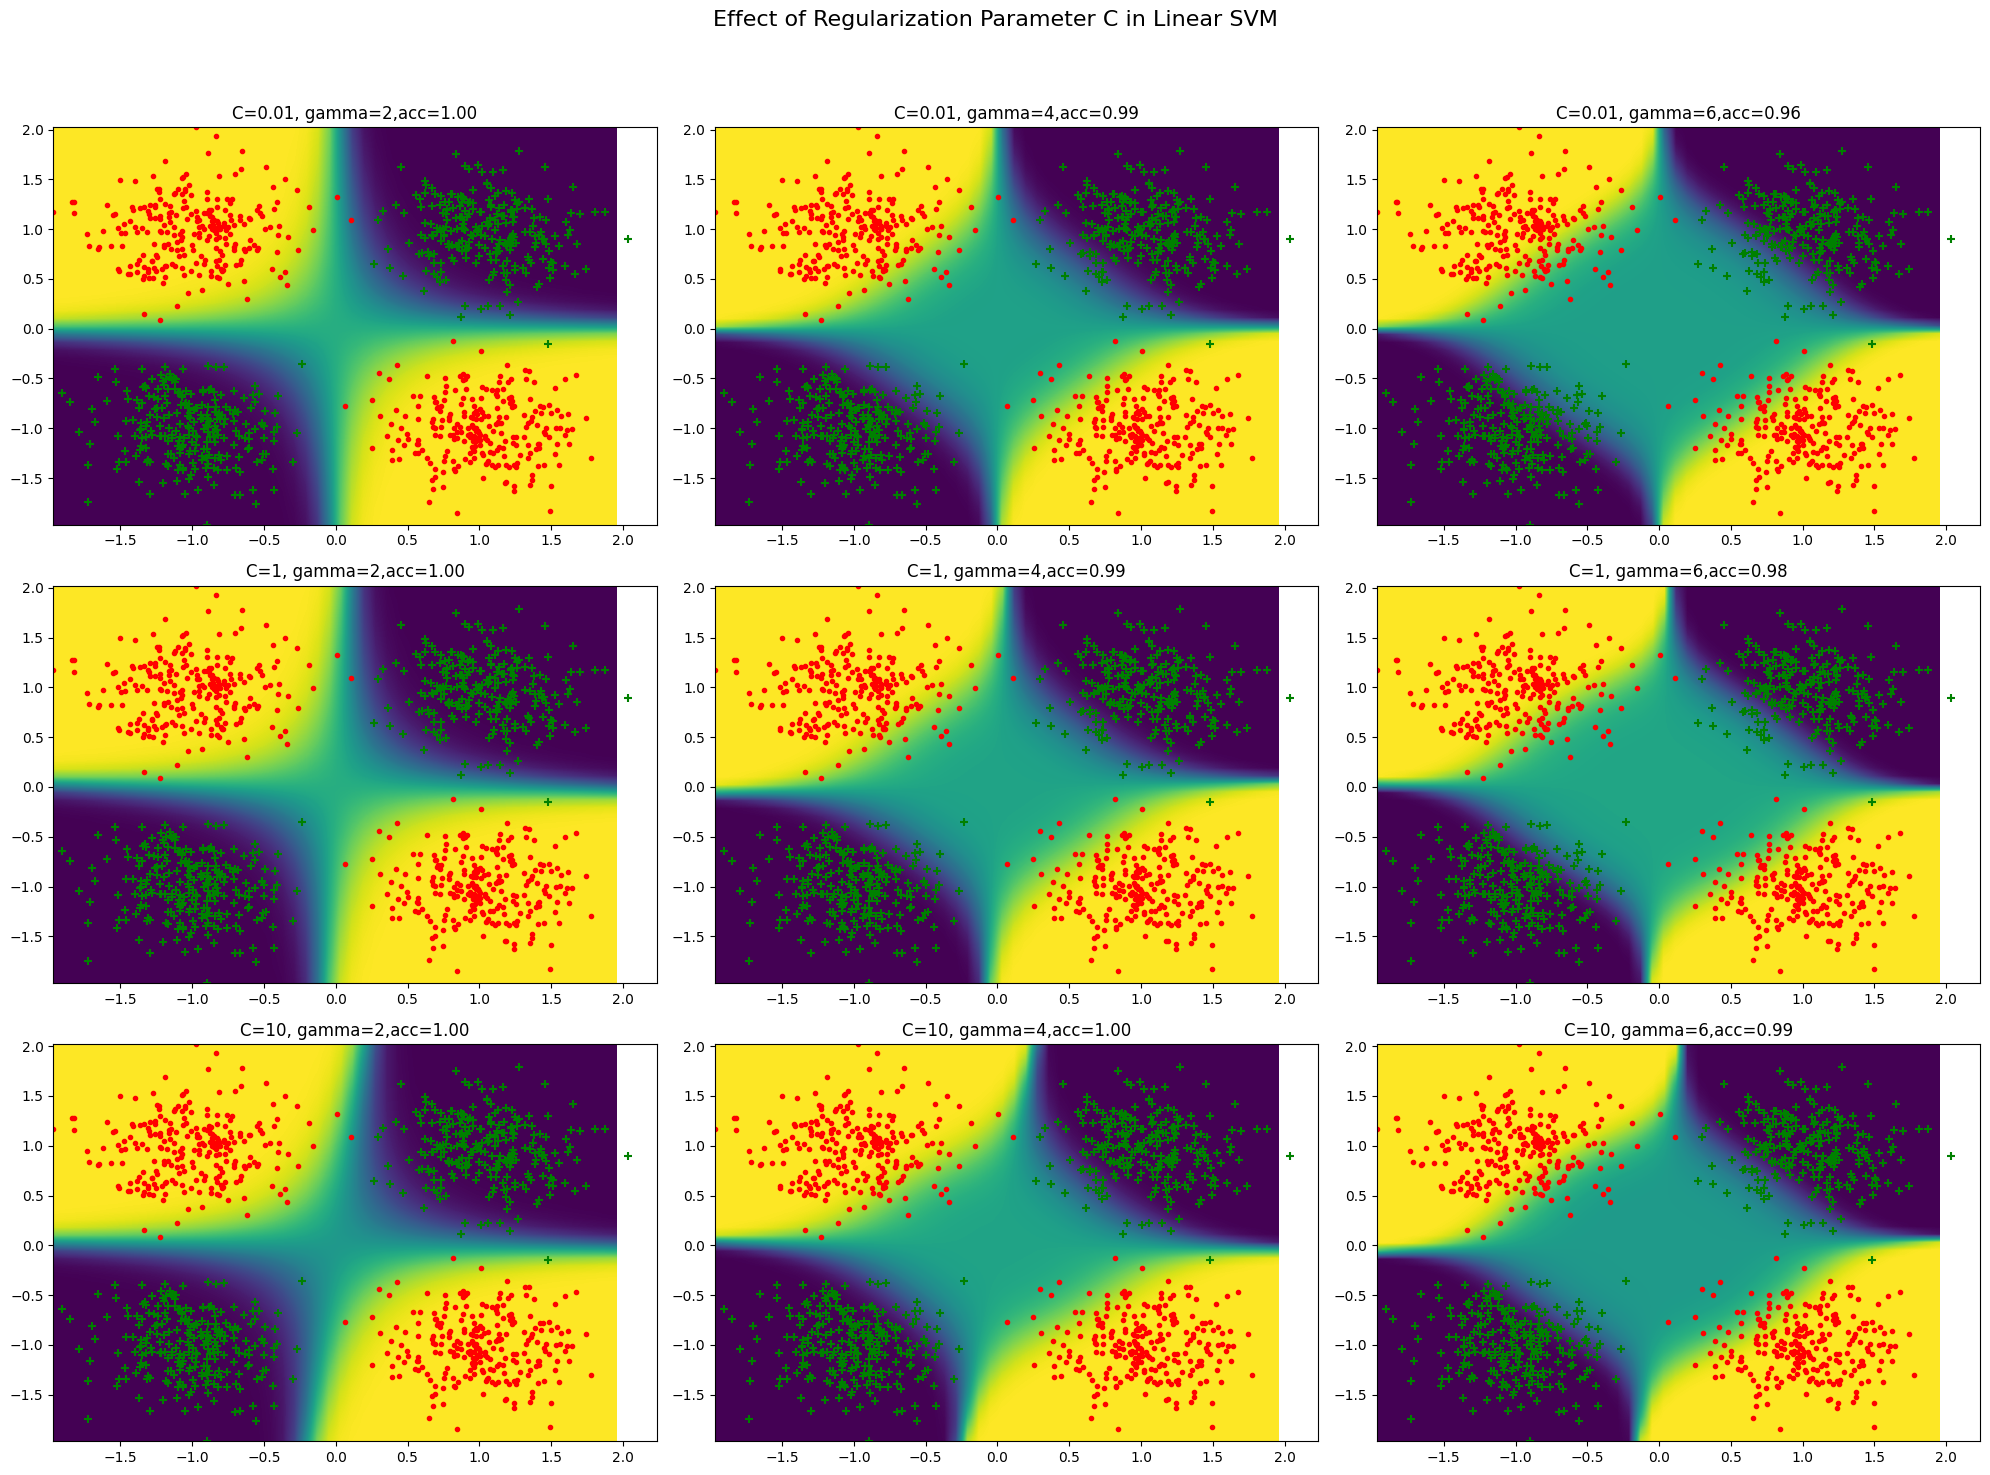

In [83]:

C_values = [0.01, 1,10]
poly_degrees = [2, 4, 6]


fig, axes = plt.subplots(len(C_values), len(poly_degrees), figsize=(20, 15))

for i, C_val in enumerate(C_values):
    for j, degrees in enumerate(poly_degrees):

        svm = SVC(kernel='poly', degree = degrees, C=C_val, probability=True)
        svm.fit(X_train, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test))
        sv = svm.support_vectors_
        print(f"Support Vectors for C={C_val}, degree={degrees}: {len(sv)}")
        ax = axes[i,j]
        plt.sca(ax)
        plot_frontiere_proba(datax, lambda x: svm.predict_proba(x)[: ,0] , step=50)
        plot_data(datax, datay)
        ax.set_title(f"C={C_val}, gamma={degrees},acc={acc:.2f}")

plt.suptitle("Effect of Regularization Parameter C in Linear SVM", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Results 

With polynomial kernel again we cannot see that much sensitivity to the parameters. However, again from the data we see that low C values use many point as support vectors compared to higher values of C. 

## Grid search

This is a method to find the most optimal parameters

In [84]:
from sklearn.model_selection import GridSearchCV

In [71]:
datax, datay = gen_arti(nbex=100, data_type=1)
X_train, X_test, y_train, y_test = train_test_split(datax, datay, test_size=0.3, random_state=42)
y_train = y_train.ravel()
y_test = y_test.ravel()

Kernel: linear
Best parameters:  {'C': 10}
Accuracy:  0.7033333333333334


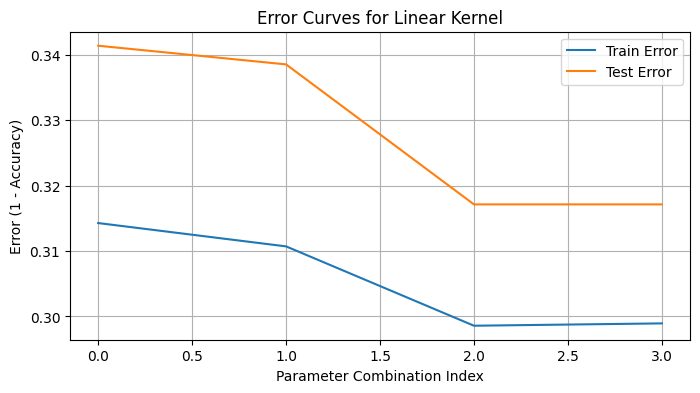

Kernel: rbf
Best parameters:  {'C': 0.1, 'gamma': 0.1}
Accuracy:  1.0


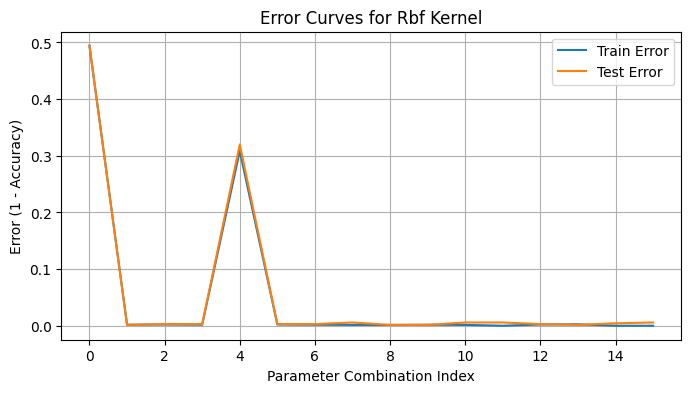

Kernel: poly
Best parameters:  {'C': 0.1, 'degree': 2}
Accuracy:  1.0


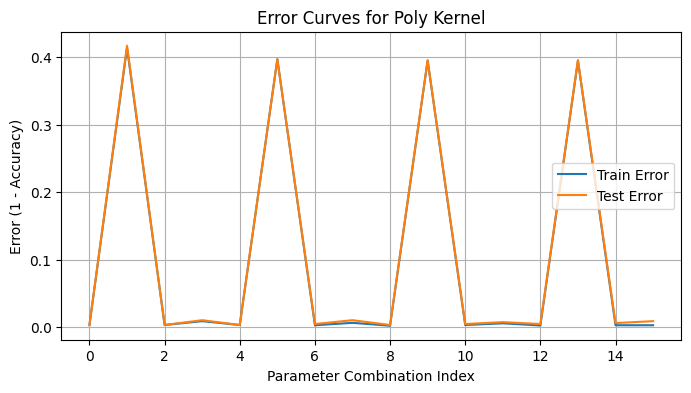

In [89]:
params_grid = {
    "linear": {"C": [0.1, 1, 10, 100]},
    "rbf": {"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, 10]},
    "poly": {"C": [0.1, 1, 10, 100], "degree": [2, 3, 4, 6]}
}
for kernel, param_grid in params_grid.items():
    print(f"Kernel: {kernel}")
    svc = SVC(kernel=kernel)
    grid = GridSearchCV(svc, param_grid, cv=5, return_train_score=True)
    grid.fit(X_train, y_train)
    best_params = grid.best_params_
    print("Best parameters: ", best_params)
    final_model = SVC(kernel=kernel, **best_params)
    final_model.fit(X_train, y_train)
    score = final_model.score(X_test, y_test)
    print('Accuracy: ', score)

    results = grid.cv_results_
    mean_train_score = 1 - np.array(results['mean_train_score'])
    mean_val_score = 1 - np.array(results['mean_test_score'])
    
    plt.figure(figsize=(8, 4))
    plt.plot(mean_train_score, label='Train Error')
    plt.plot(mean_val_score, label='Test Error')
    plt.title(f"Error Curves for {kernel.capitalize()} Kernel")
    plt.xlabel("Parameter Combination Index")
    plt.ylabel("Error (1 - Accuracy)")
    plt.legend()
    plt.grid(True)
    plt.show()


### Results 

Results show optimal parameters to be C=1 in linear kernel, 0.1 in rbf and polynomial, 2 degree polynomial and gamma. This is in line with what we have seen in the graphs above. C 0.1 ia a medium value for c parameter so it is line with the observation and previous predictions. As we can see the error flactuates for rbf and polynomial kernel. This means that the model performnace is dependent on the parameter combinations. We should be careful when choosing parameters not to introduce error. 


## Kernel string

In [90]:
from itertools import combinations

def l(s, sub):
    result = []
    substring_len = len(sub)
    
    for indices in combinations(range(len(s)), substring_len):
        if ''.join(s[i] for i in indices) == sub:
            i1 = indices[0]
            i_last = indices[-1]
            l_value = i_last - i1 + 1
            result.append((indices, l_value))
    return result

def phi_u(s, sub, lambd):
    l_i = l(s, sub)  
    total = 0
    for _, l_value in l_i:
        total += lambd ** l_value
    return total


def string_kernel(s, t, n, lambd):
    
    alphabet = sorted(set(s + t))
    all_u = [''.join(u) for u in combinations(alphabet, n)]
    
    kernel_value = 0
    for u in all_u:
        phi_s = phi_u(s, u, lambd)
        phi_t = phi_u(t, u, lambd)
        kernel_value += phi_s * phi_t
    
    return kernel_value



In [91]:
texts= ["We can now bring you the first comments from the UK to the news that Pakistan and India have agreed to a ceasefire. Foreign Secretary David Lammy says the ceasefire is hugely welcome in a post on social media.I urge both parties to sustain this. De-escalation is in everybodys interest, he adds.",
"Modify your fit method to support stochastic descent (examples are randomly ordered and only one example is used to compute the gradient and update weights) and mini-batch descent (the dataset is divided into small random batches of m examples, the gradient is averaged over each batch before updating)."]

labels = [0, 1]

def preprocess(text):
    return ''.join([c.lower() for c in text if c.isalpha()])

texts_clean = [preprocess(t) for t in texts]

n=3
lambd = 0.5

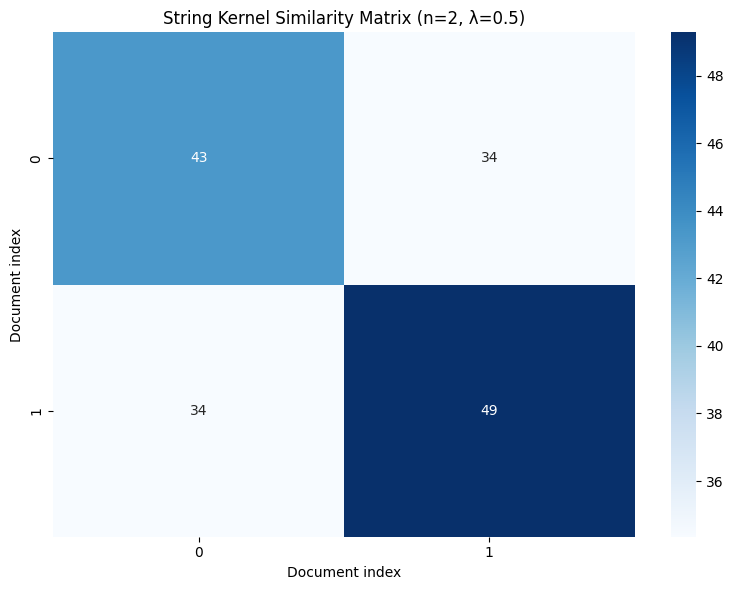

In [94]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

texts = [
    "We can now bring you the first comments from the UK to the news that Pakistan and India have agreed to a ceasefire. Foreign Secretary David Lammy says the ceasefire is hugely welcome in a post on social media. I urge both parties to sustain this. De-escalation is in everybody's interest, he adds.",
    "Modify your fit method to support stochastic descent (examples are randomly ordered and only one example is used to compute the gradient and update weights) and mini-batch descent (the dataset is divided into small random batches of m examples, the gradient is averaged over each batch before updating)."
]

labels = [0, 1]

def preprocess(text):
    return ''.join([c.lower() for c in text if c.isalpha()])


texts_clean = [preprocess(t) for t in texts]

def l(s, sub):
    result = []
    substring_len = len(sub)
    
    for indices in combinations(range(len(s)), substring_len):
        if ''.join(s[i] for i in indices) == sub:
            i1 = indices[0]
            i_last = indices[-1]
            l_value = i_last - i1 + 1
            result.append((indices, l_value))
    return result


def phi_u(s, sub, lambd):
    l_i = l(s, sub)
    total = 0
    for _, l_value in l_i:
        total += lambd ** l_value
    return total

# 
def string_kernel(s, t, n, lambd):
    alphabet = sorted(set(s + t)) 
    all_u = [''.join(u) for u in combinations(alphabet, n)] 
    
    kernel_value = 0
    for u in all_u:
        phi_s = phi_u(s, u, lambd)
        phi_t = phi_u(t, u, lambd)
        kernel_value += phi_s * phi_t
    
    return kernel_value

n = 2  
lambd = 0.5  

size = len(texts_clean)
sim_matrix = np.zeros((size, size))

for i in range(size):
    for j in range(size):
        sim_matrix[i, j] = string_kernel(texts_clean[i], texts_clean[j], n=n, lambd=lambd)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"String Kernel Similarity Matrix (n={n}, λ={lambd})")
plt.xlabel("Document index")
plt.ylabel("Document index")
plt.tight_layout()
plt.show()




## Results 

Similarity matrix shows us how similar the two texts are. Since i used texts that are not related at all around 50% resesmbles make sense. If we would take txts from the same article we would expect higher similarity index. 